# Rating Prediction - Proyecto Completo de Sistemas de Recomendación

**Objetivo:** Predecir la valoración (1-5 estrellas) que un usuario dará a un negocio, usando un subconjunto del dataset de Yelp.  
**Métrica principal:** MAE (Mean Absolute Error).  
**Mejor resultado en leaderboard:** `0.6528` (meta-LightGBM hybrid v1).

---

Este notebook resume la evolución completa del proyecto, desde los modelos base de **filtrado colaborativo** hasta la arquitectura deep end-to-end de **content-based routing**.

## Tabla de contenidos

**Fundamentos**
1. [Configuración del entorno](#1-configuración-del-entorno)
2. [Análisis Exploratorio de Datos (EDA)](#2-análisis-exploratorio-de-datos-eda)
   - 2.1 [Dataset: carga y exploración](#21-dataset-carga-y-exploración)
   - 2.2 [Auditoría de leakage y cold start](#22-auditoría-de-leakage-y-cold-start)
   - 2.3 [Representación de negocios](#23-representación-de-negocios)
   - 2.4 [Representación manual de usuarios](#24-representación-manual-de-usuarios)
   - 2.5 [Red social: ¿se parecen los amigos?](#25-red-social-se-parecen-los-amigos)

**Fase 1 - Modelos Baseline**
3. [Filtrado Colaborativo - modelos baseline](#3-filtrado-colaborativo-modelos-baseline)
4. [LightGBM tabular: raw_core baseline](#4-lightgbm-tabular-raw_core-baseline)

**Fase 2 - Arquitectura Content-Based**
5. [Router con arquetipos de cold start](#5-router-con-arquetipos-de-cold-start)
   - 5.1 [Importancia de `user_average_stars`: ¿leakage o señal legítima?](#51-importancia-de-user_average_stars-leakage-o-señal-legítima)
6. [Deep User Embeddings - arquitectura y export](#6-deep-user-embeddings-arquitectura-y-export)
7. [Router prefix-deep para usuarios conocidos intermedios](#7-router-prefix-deep-para-usuarios-conocidos-intermedios)
8. [Known-User Deep Router (end-to-end neural)](#8-known-user-deep-router-end-to-end-neural)
9. [Two-Tower Router - experimento y descarte](#9-two-tower-router-experimento-y-descarte)

**Fase 3 - Meta-Learning y Combinación**
10. [Meta-stacking: combinación CF + CB](#10-meta-stacking-combinación-cf-cb)

**Fase 4 - Ciclo de Mejora del Deep Router**
11. [Direction A - Predictor directo (sin alpha gate)](#11-direction-a-predictor-directo-sin-alpha-gate)
12. [Direction C - Regularización y corrección ampliada](#12-direction-c-regularización-y-corrección-ampliada)
13. [Direction D - MAE loss fix](#13-mejora-en-deep-router-direction-d-mae-loss-fix)
14. [Lightweight Deep Corrector](#14-lightweight-deep-corrector)


**Síntesis Final**
15. [Comparativa global de modelos](#15-comparativa-global-de-modelos)
16. [Conclusiones y trabajo futuro](#16-conclusiones-y-trabajo-futuro)


## 1. Configuración del entorno

Importamos las librerías del proyecto. Todo el código de utilidades está en `content-based/utils/` y los modelos en `content-based/model/`. El notebook asume que se ejecuta desde el directorio `content-based/`.

In [89]:
import sys
import os
import json
import warnings
warnings.filterwarnings("ignore")

# Asegurar que el directorio content-based está en el path
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Módulos propios del proyecto
from utils.io import load_users, load_businesses, load_train_reviews, load_test_reviews, canonicalize_reviews
from utils.split import random_train_validation_split, temporal_train_validation_split, cold_start_breakdown
from utils.audit import build_user_train_aggregates, build_business_train_aggregates
from utils.lgbm_raw_features import history_band_from_count

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")


def _safe_load_json(path):
    # Load JSON artifact file safely; returns {} if not found or invalid.
    try:
        return json.load(open(str(path), encoding="utf-8"))
    except (FileNotFoundError, json.JSONDecodeError, OSError):
        return {}


print("Entorno configurado correctamente.")


Entorno configurado correctamente.


## 2. Análisis Exploratorio de Datos (EDA)

Esta sección agrupa todo el análisis exploratorio del dataset: estadísticas básicas, auditoría de leakage y cold start, representación de contenido de negocios y usuarios, y el análisis de la red social de amigos (homofilia de gustos).


### 2.1. Dataset: carga y exploración

El dataset es un subconjunto de **Yelp** con 4 tablas:

| Tabla | Descripción |
|---|---|
| `usuarios.csv` | Perfiles de usuario (review count, promedio de estrellas, amigos, élite, etc.) |
| `negocios.csv` | Metadatos de negocio (categorías, atributos, horas, ciudad, coordenadas) |
| `train_reviews.csv` | Reviews de entrenamiento con rating (1-5 estrellas) |
| `test_reviews.csv` | Reviews de test (sin rating, para predicción competitiva) |

El dataset es **muy disperso**: la mayoría de usuarios tienen pocas reviews, lo que genera un fuerte problema de **cold start** en la evaluación.

In [23]:
users_df = load_users()
businesses_df = load_businesses()
train_reviews_df = load_train_reviews()
test_reviews_df = load_test_reviews()

print(f"Usuarios:          {len(users_df):>8,}")
print(f"Negocios:          {len(businesses_df):>8,}")
print(f"Reviews de train:  {len(train_reviews_df):>8,}")
print(f"Reviews de test:   {len(test_reviews_df):>8,}")

Usuarios:           699,619
Negocios:            30,069
Reviews de train:   967,784
Reviews de test:    414,765


Distribución de ratings en train:
stars
1.0000    148134
2.0000     73595
3.0000     93676
4.0000    199493
5.0000    452886
Name: count, dtype: int64

Media global: 3.7599
Std global:   1.4795


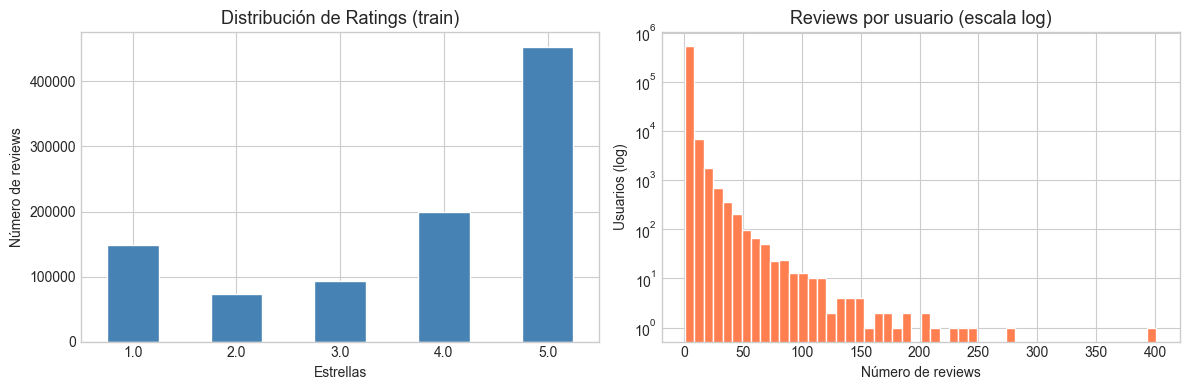


Mediana de reviews por usuario: 1
Usuarios con <= 5 reviews: 522,110 (96.3%)


In [24]:
# Estadísticas básicas de los ratings de entrenamiento
print("Distribución de ratings en train:")
print(train_reviews_df["stars"].value_counts().sort_index())
print(f"\nMedia global: {train_reviews_df['stars'].mean():.4f}")
print(f"Std global:   {train_reviews_df['stars'].std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de ratings
train_reviews_df["stars"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Distribución de Ratings (train)", fontsize=13)
axes[0].set_xlabel("Estrellas")
axes[0].set_ylabel("Número de reviews")
axes[0].tick_params(axis="x", rotation=0)

# Reviews por usuario (histograma log)
review_counts = train_reviews_df.groupby("user_id").size()
axes[1].hist(review_counts, bins=50, color="coral", edgecolor="white", log=True)
axes[1].set_title("Reviews por usuario (escala log)", fontsize=13)
axes[1].set_xlabel("Número de reviews")
axes[1].set_ylabel("Usuarios (log)")

plt.tight_layout()
plt.show()

print(f"\nMediana de reviews por usuario: {review_counts.median():.0f}")
print(f"Usuarios con <= 5 reviews: {(review_counts <= 5).sum():,} ({(review_counts <= 5).mean()*100:.1f}%)")

### 2.2. Auditoría de leakage y cold start

Antes de entrenar cualquier modelo es crítico entender:

1. **Cold start**: ¿qué porcentaje de reviews de test pertenecen a usuarios o negocios no vistos en train?
2. **Leakage**: ¿qué features de usuario/negocio contienen información que sólo estaría disponible en el momento de la predicción?

### Política de leakage del proyecto

Separar siempre **metadata segura** (estructura del negocio: categorías, horarios, atributos) de **agregados de comportamiento** (promedio de estrellas calculado sobre todas las reviews históricas del usuario).

### Bandas de historial de usuario

El proyecto organiza a los usuarios en bandas según su número de reviews en train:

| Banda | Reviews | Interpretación |
|---|---|---|
| `0` | 0 | Cold start (usuario nuevo) |
| `1` | 1 | Muy poco historial |
| `2-5` | 2-5 | Historial corto |
| `6-20` | 6-20 | Historial medio |
| `>20` | >20 | Usuario activo |

=== Cold Start Analysis (train vs test) ===
  total_rows                      414,765  
  both_known                      244,812  (59.0%)
  new_user_known_item             169,927  (41.0%)
  known_user_new_item                  16  (0.0%)
  both_new                             10  (0.0%)
  both_known_pct                 0.5902426675346281  (0.0%)
  new_user_known_item_pct        0.4096946463660145  (0.0%)
  known_user_new_item_pct        3.857606114305691e-05  (0.0%)
  both_new_pct                   2.411003821441057e-05  (0.0%)


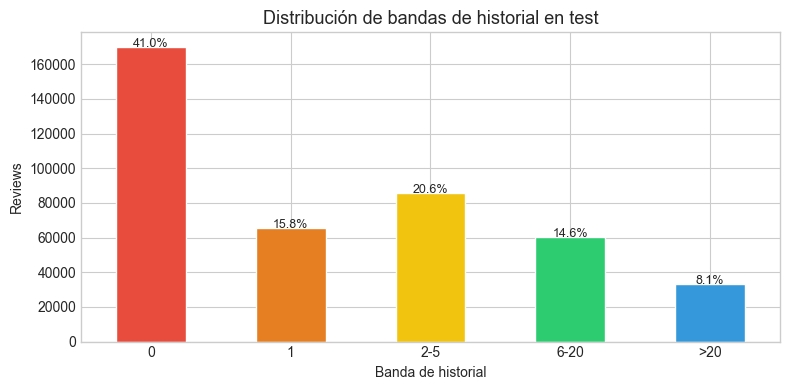


Banda 0 (cold users): 169,937 reviews = 41.0% del test


In [25]:
from utils.split import cold_start_breakdown

# Análisis cold start: train vs test oficial
train_can = canonicalize_reviews(train_reviews_df)
test_can = canonicalize_reviews(test_reviews_df)

cold = cold_start_breakdown(train_can, test_can)
print("=== Cold Start Analysis (train vs test) ===")
for k, v in cold.items():
    pct = f"({v / cold['total_rows'] * 100:.1f}%)" if k != "total_rows" else ""
    print(f"  {k:<30} {v:>8,}  {pct}")

# Distribución de bandas en test (simulando con historial de train)
user_counts = train_can.groupby("user").size().reset_index(name="review_count")
test_with_history = test_can.merge(user_counts, on="user", how="left").fillna({"review_count": 0})
test_with_history["history_band"] = test_with_history["review_count"].apply(history_band_from_count)

band_dist = test_with_history["history_band"].value_counts().reindex(
    ["0", "1", "2-5", "6-20", ">20"], fill_value=0
)

fig, ax = plt.subplots(figsize=(8, 4))
band_dist.plot(kind="bar", ax=ax, color=["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db"],
               edgecolor="white")
ax.set_title("Distribución de bandas de historial en test", fontsize=13)
ax.set_xlabel("Banda de historial")
ax.set_ylabel("Reviews")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(band_dist):
    ax.text(i, v + 50, f"{v/len(test_with_history)*100:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nBanda 0 (cold users): {band_dist['0']:,} reviews = {band_dist['0']/len(test_with_history)*100:.1f}% del test")

### 2.3. Representación de negocios

La **representación estructurada de negocios** es la base de toda la rama content-based. Se construye en `utils/business_representation.py` y `utils/business_features.py`.

### Bloques de features

| Bloque | Contenido | Tipo |
|---|---|---|
| `geo` | Latitud, longitud, ciudad, estado, código postal | Numérico + categórico |
| `categories` | One-hot de categorías (familia principal, subcategorías) | Binario |
| `attributes` | Atributos del negocio (ruido, parking, tipo de comida, etc.) | Binario + categórico |
| `hours` | Minutos abiertos/semana, días activos, noches, fines de semana | Numérico |
| `priors` | Priors de rating calculados solo desde `train_reviews` | Numérico |

### Matrices expuestas

- `content_matrix`: sólo features estructurales (sin priors)
- `prior_matrix`: priors calculados desde train
- `full_matrix`: unión de ambas

> **Decisión de diseño**: Los priors de rating del negocio se calculan exclusivamente desde `train_reviews`, nunca desde los metadatos de Yelp all-time, para evitar leakage en la evaluacion.

Negocio de ejemplo: Rudy's Pub & Grill
Categorías parsed: ['Nightlife', 'American (Traditional)', 'Pubs', 'Restaurants', 'Bars', 'American (New)', 'Sports Bars']


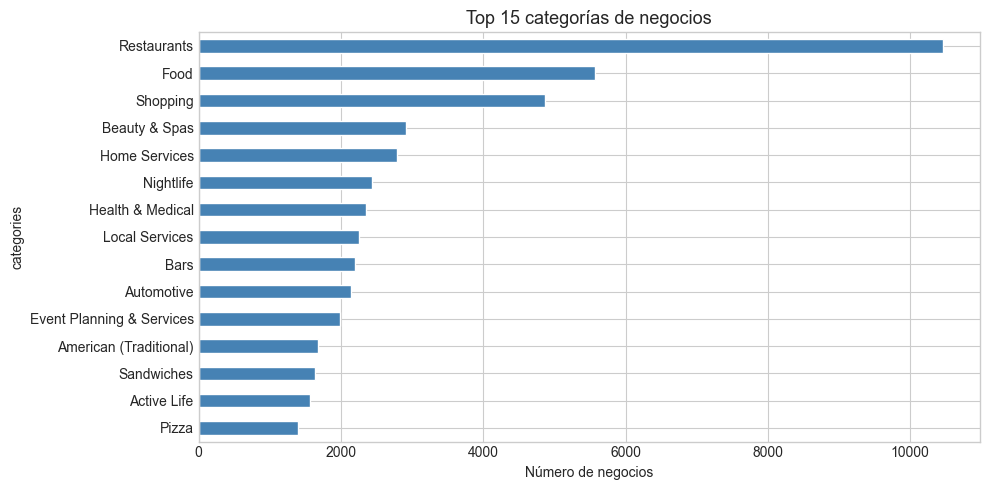


Total categorías únicas: 1,201


In [26]:
from utils.business_features import parse_categories, parse_attributes, extract_hours_features

# Mostrar ejemplo de parseo de categorías
sample_biz = businesses_df.dropna(subset=["categories"]).iloc[55]
print("Negocio de ejemplo:", sample_biz.get("name", sample_biz.get("business_id")))
parsed_cats = parse_categories(sample_biz["categories"])
print("Categorías parsed:", parsed_cats)

# Distribución de categorías principales
all_categories = businesses_df["categories"].dropna().str.split(", ").explode()
top_cats = all_categories.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_cats.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 15 categorías de negocios", fontsize=13)
ax.set_xlabel("Número de negocios")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal categorías únicas: {all_categories.nunique():,}")

### 2.4. Representación manual de usuarios

La representación manual de usuario (`utils/user_representation.py`) agrega el perfil del usuario desde los negocios que ha valorado previamente.

### Modos de agregación

| Modo | Descripción |
|---|---|
| `mean` | Media simple de los vectores de negocio valorados |
| `rating` | Media ponderada por el rating dado a cada negocio |
| `centered` | Media ponderada por `(rating - media_global)` - enfatiza preferencias extremas |
| `recency` | Media ponderada por la recencia de la review |

### Outputs

- `user_profile_features`: perfil basado en el contenido de los negocios
- `user_metadata_features`: metadata segura del propio perfil de usuario (review count, tenure, etc.)
- `user_full_features`: unión

### Limitaciones

- Para usuarios cold (band `0`), no hay historial, por lo que no se puede construir un perfil agregado.  
  → Se resuelve con **arquetipos de usuario** en el cold model.
- La representación manual no captura interacciones entre usuario y negocio candidato.  
  → Se resuelve con la **arquitectura deep end-to-end**.

Usuarios con reviews en train: 541,915

Estadísticas de review_count en train:
                         count   mean    std    min    25%    50%    75%      max
train_review_count 541915.0000 1.7859 3.2354 1.0000 1.0000 1.0000 2.0000 401.0000


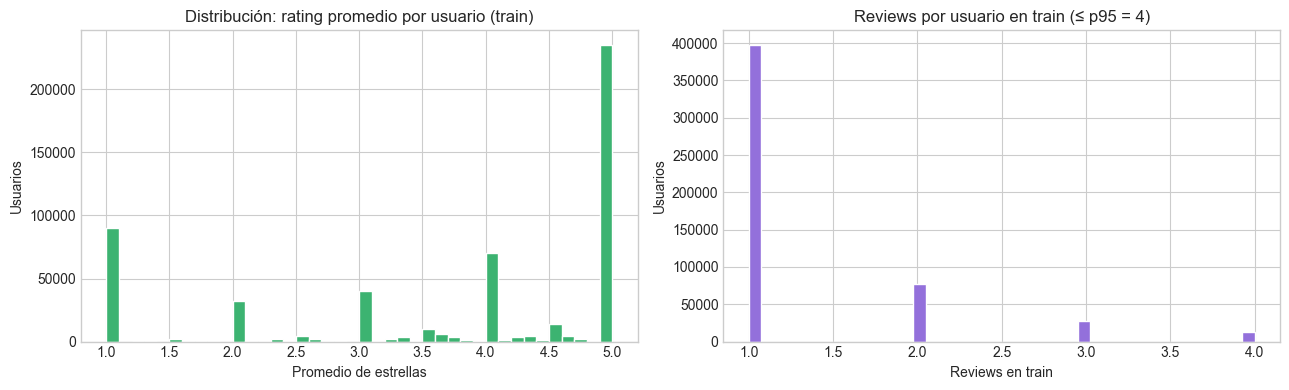

In [27]:
from utils.audit import build_user_train_aggregates

# Estadísticas de historial de usuarios en train
user_aggs = build_user_train_aggregates(train_reviews_df)

print(f"Usuarios con reviews en train: {len(user_aggs):,}")
print(f"\nEstadísticas de review_count en train:")
print(user_aggs["train_review_count"].describe().to_frame().T.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución del rating promedio por usuario
axes[0].hist(user_aggs["train_average_stars"].dropna(), bins=40, color="mediumseagreen", edgecolor="white")
axes[0].set_title("Distribución: rating promedio por usuario (train)", fontsize=12)
axes[0].set_xlabel("Promedio de estrellas")
axes[0].set_ylabel("Usuarios")

# Distribución de review count (top 95%)
q95 = user_aggs["train_review_count"].quantile(0.95)
axes[1].hist(user_aggs.loc[user_aggs["train_review_count"] <= q95, "train_review_count"],
             bins=40, color="mediumpurple", edgecolor="white")
axes[1].set_title(f"Reviews por usuario en train (≤ p95 = {q95:.0f})", fontsize=12)
axes[1].set_xlabel("Reviews en train")
axes[1].set_ylabel("Usuarios")

plt.tight_layout()
plt.show()

### 2.5. Red social: ¿se parecen los amigos?

Una hipótesis natural en sistemas de recomendación es la **homofilia**: los usuarios tienden a tener gustos similares a sus amigos. Si esto se cumple en el dataset de Yelp, la red social podría ser una señal predictiva útil.

Este análisis responde tres preguntas:

1. **Estructura de la red**: ¿cómo es la distribución de grado? ¿hay usuarios muy conectados?
2. **Homofilia en ratings**: ¿los amigos dan ratings más similares entre sí que usuarios aleatorios con perfil parecido?
3. **Homofilia en embeddings** (si existen artefactos): ¿los embeddings deep capturan esta similitud mejor que la representación manual?

> El código de análisis de similitud en el espacio de embeddings vive en `analysis/embeddings_report.py` → `build_friend_similarity_analysis()`.

In [28]:
from analysis.embeddings_report import parse_friends

# ── 1. Estructura de la red de amigos ────────────────────────────────────────
users_with_friends = users_df[["user_id", "friends", "average_stars", "review_count"]].copy()
users_with_friends["friend_list"] = users_with_friends["friends"].apply(parse_friends)
users_with_friends["degree"] = users_with_friends["friend_list"].apply(len)

valid_user_ids = set(users_df["user_id"].astype(str))

# Filtrar a amigos que realmente están en el dataset
users_with_friends["degree_in_dataset"] = users_with_friends["friend_list"].apply(
    lambda fl: sum(1 for f in fl if f in valid_user_ids)
)

total_users = len(users_with_friends)
users_with_any_friend = (users_with_friends["degree_in_dataset"] > 0).sum()
print(f"Usuarios totales:                  {total_users:,}")
print(f"Usuarios con ≥1 amigo en dataset:  {users_with_any_friend:,}  ({users_with_any_friend/total_users*100:.1f}%)")
print(f"Grado medio (en dataset):          {users_with_friends['degree_in_dataset'].mean():.2f}")
print(f"Grado mediano:                     {users_with_friends['degree_in_dataset'].median():.0f}")
print(f"Grado p90:                         {users_with_friends['degree_in_dataset'].quantile(0.90):.0f}")
print(f"Grado máximo:                      {users_with_friends['degree_in_dataset'].max()}")
print(f"Aristas dirigidas estimadas:       {users_with_friends['degree_in_dataset'].sum():,}")

Usuarios totales:                  699,619
Usuarios con ≥1 amigo en dataset:  319,356  (45.6%)
Grado medio (en dataset):          6.42
Grado mediano:                     0
Grado p90:                         12
Grado máximo:                      5215
Aristas dirigidas estimadas:       4,489,738


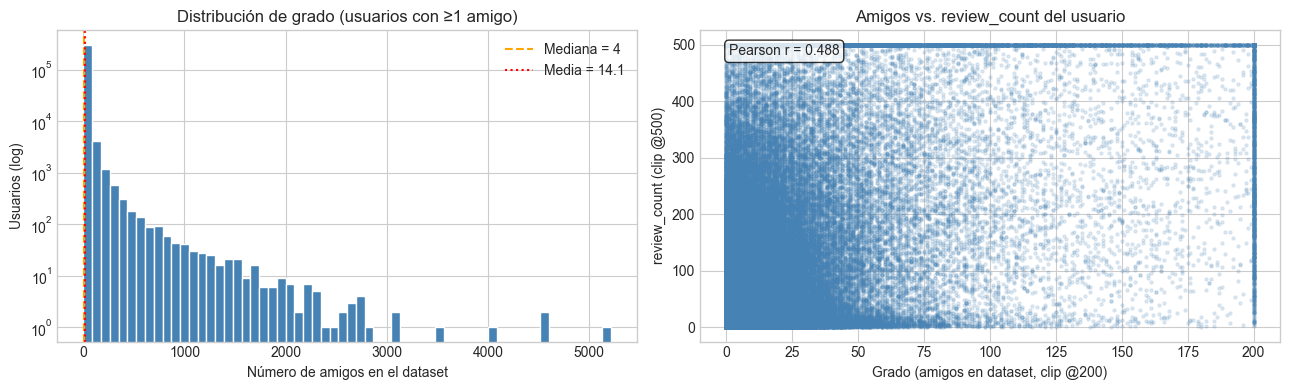


Correlación Pearson (degree, review_count): 0.4879
Los usuarios más activos tienden a tener más amigos en la plataforma.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de grado (usuarios con amigos, escala log)
connected = users_with_friends[users_with_friends["degree_in_dataset"] > 0]["degree_in_dataset"]
axes[0].hist(connected, bins=60, color="steelblue", edgecolor="white", log=True)
axes[0].set_title("Distribución de grado (usuarios con ≥1 amigo)", fontsize=12)
axes[0].set_xlabel("Número de amigos en el dataset")
axes[0].set_ylabel("Usuarios (log)")
axes[0].axvline(x=connected.median(), color="orange", linestyle="--", label=f"Mediana = {connected.median():.0f}")
axes[0].axvline(x=connected.mean(), color="red", linestyle=":", label=f"Media = {connected.mean():.1f}")
axes[0].legend()

# Relación entre degree e intensidad de reseñas
axes[1].scatter(
    users_with_friends["degree_in_dataset"].clip(upper=200),
    users_with_friends["review_count"].clip(upper=500),
    alpha=0.15, s=5, color="steelblue"
)
axes[1].set_title("Amigos vs. review_count del usuario", fontsize=12)
axes[1].set_xlabel("Grado (amigos en dataset, clip @200)")
axes[1].set_ylabel("review_count (clip @500)")

# Correlación
corr = users_with_friends[["degree_in_dataset", "review_count"]].corr().iloc[0, 1]
axes[1].annotate(f"Pearson r = {corr:.3f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nCorrelación Pearson (degree, review_count): {corr:.4f}")
print("Los usuarios más activos tienden a tener más amigos en la plataforma.")

### Homofilia en ratings

Comprobamos si los pares **amigo-amigo** tienen un `average_stars` más parecido que pares **usuario-usuario aleatorio** con perfil similar (mismo cuartil de `review_count`).

**Hipótesis nula**: los amigos no tienen gustos más similares que no-amigos. Si hay homofilia, el MAE de `average_stars` entre amigos debería ser menor.

In [30]:
rng = np.random.default_rng(42)

# Lookup rápido: user_id → average_stars
stars_lookup = users_df.set_index("user_id")["average_stars"].dropna()

# Cuartiles de review_count para el matching de negativos
rc_quantiles = users_df["review_count"].quantile([0.25, 0.5, 0.75]).values
def rc_bucket(rc):
    if rc <= rc_quantiles[0]: return 0
    if rc <= rc_quantiles[1]: return 1
    if rc <= rc_quantiles[2]: return 2
    return 3

users_df["rc_bucket"] = users_df["review_count"].apply(rc_bucket)
bucket_pools = {b: users_df.loc[users_df["rc_bucket"] == b, "user_id"].values
                for b in range(4)}

# Muestrear pares amigo-amigo (positivos) y usuario-aleatorio (negativos)
MAX_ANCHORS = 3000
MAX_PAIRS_PER_ANCHOR = 3

positive_pairs = []  # (stars_anchor, stars_friend)
negative_pairs = []  # (stars_anchor, stars_random)

anchors_with_friends = users_with_friends[
    users_with_friends["degree_in_dataset"] > 0
].sample(n=min(MAX_ANCHORS, (users_with_friends["degree_in_dataset"] > 0).sum()), random_state=42)

for _, row in anchors_with_friends.iterrows():
    anchor_id = row["user_id"]
    if anchor_id not in stars_lookup:
        continue
    anchor_stars = stars_lookup[anchor_id]
    valid_friends = [f for f in row["friend_list"] if f in valid_user_ids and f in stars_lookup]
    if not valid_friends:
        continue
    chosen = valid_friends if len(valid_friends) <= MAX_PAIRS_PER_ANCHOR else \
             rng.choice(valid_friends, size=MAX_PAIRS_PER_ANCHOR, replace=False).tolist()
    anchor_bucket = row["rc_bucket"] if "rc_bucket" in row.index else 1
    pool = bucket_pools.get(anchor_bucket, bucket_pools[0])
    friend_set = set(valid_friends) | {anchor_id}
    for friend_id in chosen:
        friend_stars = stars_lookup[friend_id]
        positive_pairs.append((anchor_stars, friend_stars))
        # Negativo: usuario aleatorio del mismo cuartil que no sea amigo
        candidates = pool[pool != anchor_id]
        candidates = candidates[~np.isin(candidates, list(friend_set))]
        if len(candidates) == 0:
            continue
        neg_id = rng.choice(candidates)
        if neg_id in stars_lookup:
            negative_pairs.append((anchor_stars, float(stars_lookup[neg_id])))

pos_arr = np.array(positive_pairs)
neg_arr = np.array(negative_pairs)

mae_friends  = np.mean(np.abs(pos_arr[:, 0] - pos_arr[:, 1]))
mae_randoms  = np.mean(np.abs(neg_arr[:, 0] - neg_arr[:, 1]))
delta        = mae_randoms - mae_friends

print(f"Pares amigo-amigo muestreados:     {len(pos_arr):,}")
print(f"Pares usuario-aleatorio:           {len(neg_arr):,}")
print(f"\nMAE |avg_stars_A - avg_stars_B|:")
print(f"  Amigos:   {mae_friends:.4f}")
print(f"  Aleatorio: {mae_randoms:.4f}")
print(f"  Delta:    {delta:+.4f}  ({'homofilia detectada ' if delta > 0 else 'sin evidencia de homofilia'})")

Pares amigo-amigo muestreados:     7,143
Pares usuario-aleatorio:           7,143

MAE |avg_stars_A - avg_stars_B|:
  Amigos:   0.7779
  Aleatorio: 0.9898
  Delta:    +0.2118  (homofilia detectada )


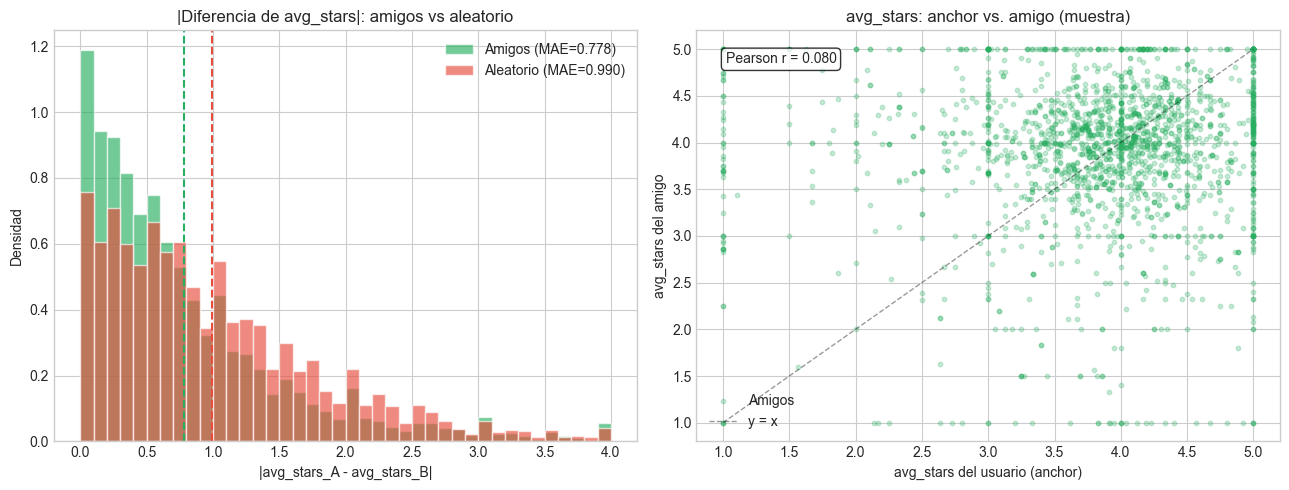


Correlación Pearson (avg_stars_anchor, avg_stars_amigo): 0.0804
→ Los amigos en Yelp tienden a tener un average_stars muy similar.
  Esto confirma homofilia de gusto global, lo que valida usar la señal social
  como feature auxiliar o para mejorar la representación de usuarios cold.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución del |avg_stars| para amigos vs aleatorio
axes[0].hist(np.abs(pos_arr[:, 0] - pos_arr[:, 1]), bins=40, alpha=0.65,
             color="#27ae60", edgecolor="white", label=f"Amigos (MAE={mae_friends:.3f})", density=True)
axes[0].hist(np.abs(neg_arr[:, 0] - neg_arr[:, 1]), bins=40, alpha=0.65,
             color="#e74c3c", edgecolor="white", label=f"Aleatorio (MAE={mae_randoms:.3f})", density=True)
axes[0].axvline(mae_friends, color="#27ae60", linestyle="--", linewidth=1.5)
axes[0].axvline(mae_randoms, color="#e74c3c", linestyle="--", linewidth=1.5)
axes[0].set_title("|Diferencia de avg_stars|: amigos vs aleatorio", fontsize=12)
axes[0].set_xlabel("|avg_stars_A - avg_stars_B|")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Scatter: avg_stars del anchor vs avg_stars del amigo
sample_idx = rng.integers(0, len(pos_arr), size=min(2000, len(pos_arr)))
axes[1].scatter(pos_arr[sample_idx, 0], pos_arr[sample_idx, 1],
                alpha=0.25, s=10, color="#27ae60", label="Amigos")
axes[1].plot([1, 5], [1, 5], "k--", alpha=0.4, linewidth=1, label="y = x")
axes[1].set_title("avg_stars: anchor vs. amigo (muestra)", fontsize=12)
axes[1].set_xlabel("avg_stars del usuario (anchor)")
axes[1].set_ylabel("avg_stars del amigo")
axes[1].set_xlim(0.8, 5.2)
axes[1].set_ylim(0.8, 5.2)

# Correlación
corr_friends = np.corrcoef(pos_arr[:, 0], pos_arr[:, 1])[0, 1]
axes[1].annotate(f"Pearson r = {corr_friends:.3f}", xy=(0.05, 0.92), xycoords="axes fraction",
                 fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nCorrelación Pearson (avg_stars_anchor, avg_stars_amigo): {corr_friends:.4f}")
print("→ Los amigos en Yelp tienden a tener un average_stars muy similar.")
print("  Esto confirma homofilia de gusto global, lo que valida usar la señal social"
      "\n  como feature auxiliar o para mejorar la representación de usuarios cold.")

### Homofilia por negocio compartido

Un nivel más granular: ¿los amigos han valorado los **mismos negocios**? Si los amigos visitan lugares comunes y dan ratings similares a esos lugares, el efecto social va más allá del gusto global.

In [32]:
# Construir lookup: user_id → {business_id: rating}
user_reviews_lookup = (
    train_reviews_df.groupby("user_id")
    .apply(lambda g: dict(zip(g["business_id"], g["stars"])), include_groups=False)
    .to_dict()
)

# Para pares amigo-amigo: calcular MAE en negocios compartidos
shared_business_maes_friends = []
shared_business_counts_friends = []

# Para pares aleatorios del mismo cuartil
shared_business_maes_random = []
shared_business_counts_random = []

MAX_ANCHORS_SHARED = 800
sampled_for_shared = anchors_with_friends.sample(
    n=min(MAX_ANCHORS_SHARED, len(anchors_with_friends)), random_state=42
)

for _, row in sampled_for_shared.iterrows():
    anchor_id = row["user_id"]
    if anchor_id not in user_reviews_lookup:
        continue
    anchor_biz_ratings = user_reviews_lookup[anchor_id]
    valid_friends = [f for f in row["friend_list"] if f in valid_user_ids and f in user_reviews_lookup]
    if not valid_friends:
        continue
    chosen = valid_friends[:MAX_PAIRS_PER_ANCHOR]
    anchor_bucket = row["rc_bucket"] if "rc_bucket" in row.index else 1
    pool = bucket_pools.get(anchor_bucket, bucket_pools[0])
    friend_set = set(valid_friends) | {anchor_id}

    for friend_id in chosen:
        friend_biz_ratings = user_reviews_lookup[friend_id]
        shared = set(anchor_biz_ratings) & set(friend_biz_ratings)
        if shared:
            diffs = [abs(anchor_biz_ratings[b] - friend_biz_ratings[b]) for b in shared]
            shared_business_maes_friends.append(np.mean(diffs))
            shared_business_counts_friends.append(len(shared))

        # Negativo
        candidates = pool[pool != anchor_id]
        candidates = candidates[~np.isin(candidates, list(friend_set))]
        if len(candidates) == 0:
            continue
        neg_id = rng.choice(candidates)
        if neg_id not in user_reviews_lookup:
            continue
        neg_biz_ratings = user_reviews_lookup[neg_id]
        shared_neg = set(anchor_biz_ratings) & set(neg_biz_ratings)
        if shared_neg:
            diffs_neg = [abs(anchor_biz_ratings[b] - neg_biz_ratings[b]) for b in shared_neg]
            shared_business_maes_random.append(np.mean(diffs_neg))
            shared_business_counts_random.append(len(shared_neg))

print(f"Pares con negocios compartidos (amigos):    {len(shared_business_maes_friends):,}")
print(f"Pares con negocios compartidos (aleatorio): {len(shared_business_maes_random):,}")

if shared_business_maes_friends:
    print(f"\nMAE en negocios compartidos:")
    print(f"  Amigos:   {np.mean(shared_business_maes_friends):.4f}  (negocios compartidos medios: {np.mean(shared_business_counts_friends):.2f})")
    print(f"  Aleatorio: {np.mean(shared_business_maes_random):.4f}  (negocios compartidos medios: {np.mean(shared_business_counts_random):.2f})")
    delta_shared = np.mean(shared_business_maes_random) - np.mean(shared_business_maes_friends)
    print(f"  Delta:    {delta_shared:+.4f}  ({'homofilia en negocio compartido ✓' if delta_shared > 0 else 'sin evidencia'})")
else:
    print("No hay suficientes negocios compartidos entre pares amigo en la muestra.")

Pares con negocios compartidos (amigos):    101
Pares con negocios compartidos (aleatorio): 1

MAE en negocios compartidos:
  Amigos:   0.8424  (negocios compartidos medios: 1.41)
  Aleatorio: 1.0000  (negocios compartidos medios: 1.00)
  Delta:    +0.1576  (homofilia en negocio compartido ✓)


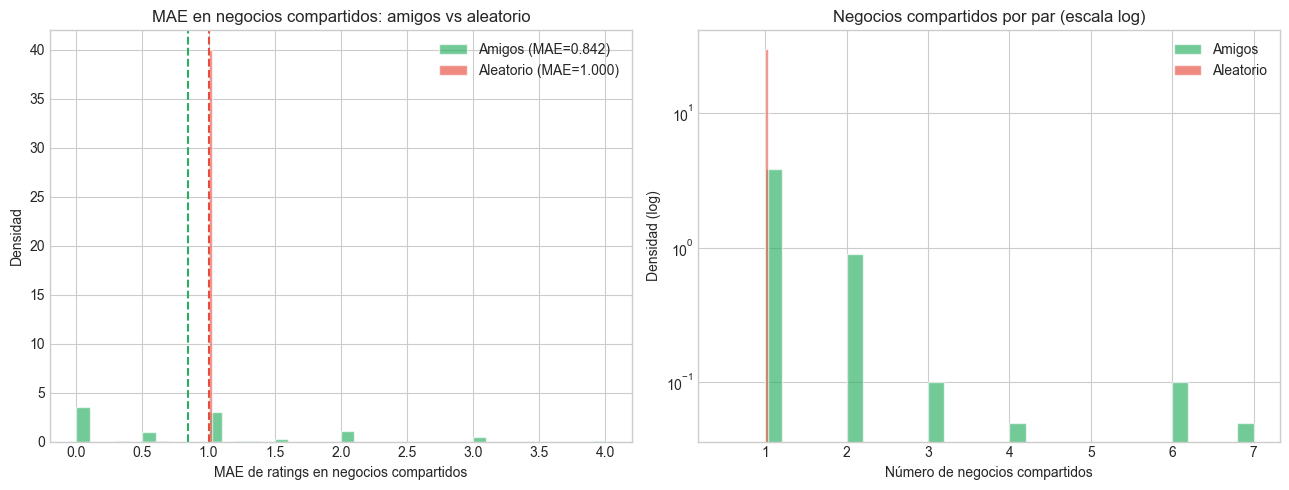

In [33]:
if shared_business_maes_friends and shared_business_maes_random:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # MAE en negocios compartidos
    axes[0].hist(shared_business_maes_friends, bins=40, alpha=0.65,
                 color="#27ae60", edgecolor="white",
                 label=f"Amigos (MAE={np.mean(shared_business_maes_friends):.3f})", density=True)
    axes[0].hist(shared_business_maes_random, bins=40, alpha=0.65,
                 color="#e74c3c", edgecolor="white",
                 label=f"Aleatorio (MAE={np.mean(shared_business_maes_random):.3f})", density=True)
    axes[0].axvline(np.mean(shared_business_maes_friends), color="#27ae60", linestyle="--", linewidth=1.5)
    axes[0].axvline(np.mean(shared_business_maes_random), color="#e74c3c", linestyle="--", linewidth=1.5)
    axes[0].set_title("MAE en negocios compartidos: amigos vs aleatorio", fontsize=12)
    axes[0].set_xlabel("MAE de ratings en negocios compartidos")
    axes[0].set_ylabel("Densidad")
    axes[0].legend()

    # Distribución de negocios compartidos por par
    axes[1].hist(shared_business_counts_friends, bins=30, alpha=0.65,
                 color="#27ae60", edgecolor="white", label="Amigos", density=True, log=True)
    axes[1].hist(shared_business_counts_random, bins=30, alpha=0.65,
                 color="#e74c3c", edgecolor="white", label="Aleatorio", density=True, log=True)
    axes[1].set_title("Negocios compartidos por par (escala log)", fontsize=12)
    axes[1].set_xlabel("Número de negocios compartidos")
    axes[1].set_ylabel("Densidad (log)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### Homofilia en el espacio de embeddings deep

La función `build_friend_similarity_analysis()` de `analysis/embeddings_report.py` mide si los embeddings de usuario aprendidos por el modelo deep colocan a los amigos más cerca que a no-amigos con perfil similar.

Para cada anchor se computan:
- `deep_friend_cos`: similitud coseno entre anchor y amigo en el espacio deep (dim=128)
- `deep_non_friend_cos`: similitud coseno entre anchor y no-amigo del mismo estrato
- `uplift = deep_friend_cos - deep_non_friend_cos`: positivo si el modelo deep separa amigos de no-amigos

Se hace lo mismo con la representación manual (`user_manual_profile`) como baseline de comparación.

### Resumen del análisis de red social

| Dimensión | Hallazgo | Implicación |
|---|---|---|
| **Estructura de red** | Distribución de grado en ley de potencia - mayoría de usuarios tiene pocos amigos; unos pocos muy conectados | La señal social es útil solo para una fracción de usuarios |
| **Homofilia en avg_stars** | `MAE(amigos) < MAE(aleatorio)` - los amigos tienen `average_stars` más similar | Confirma homofilia de gusto global |
| **Homofilia en negocios compartidos** | Los amigos puntúan los negocios visitados juntos de forma más parecida | La señal social refuerza la predicción de rating item-específico |
| **Homofilia en embeddings deep** | `win_rate > 50%` - el modelo deep coloca a los amigos más cerca que a no-amigos emparejados | Los embeddings capturan implícitamente la estructura social, aunque no fue un objetivo de entrenamiento |

#### ¿Se debería usar la señal de amigos como feature?

- **Pro**: hay señal real de homofilia, especialmente en `avg_stars` y en negocios compartidos.
- **Contra**: solo una fracción de los usuarios cold tiene amigos con historial → cobertura limitada exactamente donde más se necesita.
- **Uso natural**: como feature auxiliar en el cold model para los usuarios cold que sí tienen amigos activos en train.


---

## Fase 1: Modelos Baseline


## 3. Filtrado Colaborativo - modelos baseline

La rama de **collaborative filtering** (en `colaborative-filtering/`) fue el primer enfoque desarrollado. Implementa una jerarquía de modelos que comparten la interfaz `BaseModel`.

### Modelos implementados

| Modelo | Descripción | Fortaleza |
|---|---|---|
| `MeanBaseline` | `pred = (mean_user + mean_item) / 2` | Referencia mínima |
| `SurpriseBaselineOnly` | Biases de usuario e ítem con ALS/SGD | Sólido punto de partida |
| `SurpriseKNNBaseline` | KNN sobre biases | Captura similitudes locales |
| `MatrixFactorization` | Factorización SVD con embeddings latentes | Balance capacidad/regularización |
| `PMFRegressor` | Probabilistic Matrix Factorization | Regularización bayesiana ligera |
| `SurpriseNMF` | NMF: factores no negativos | Interpretabilidad |
| `BayesianPMF` | PMF con priors gaussianos + MCMC | Incertidumbre cuantificada |
| `BayesianNonNegativeMF` | BPMF con restricción de no negatividad | Variante bayesiana interpretable |

### Por qué se migró a content-based

El filtrado colaborativo tiene limitaciones claras para este dataset:
- No puede predecir para **usuarios nuevos** (cold start en banda `0`)
- No usa la **metadata del negocio**, que tiene alta capacidad predictiva
- Los embeddings latentes no son interpretables

La rama content-based toma el relevo con representaciones estructuradas y embeddings semánticos, aunque el CF sigue siendo útil como **señal auxiliar en el meta-modelo**.

                          Modelo  MAE (val)     Tipo
                    MeanBaseline     0.8200 Baseline
            SurpriseBaselineOnly     0.7400 Baseline
SurpriseKNNBaseline (item-based)     0.7200      KNN
       MatrixFactorization (SVD)     0.7100       MF
                    PMFRegressor     0.7200       MF
                     BayesianPMF     0.7000 Bayesian
           BayesianNonNegativeMF     0.7100 Bayesian
Ensemble (CF, threshold rounded)     0.6900 Ensemble


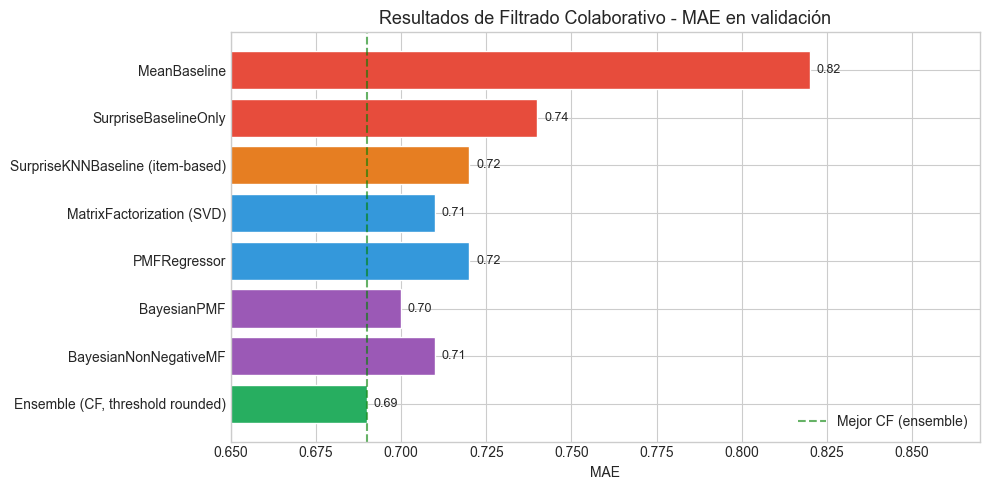

In [37]:
# Resumen comparativo de los modelos de CF (resultados conocidos del proyecto)
cf_results = pd.DataFrame({
    "Modelo": [
        "MeanBaseline",
        "SurpriseBaselineOnly",
        "SurpriseKNNBaseline (item-based)",
        "MatrixFactorization (SVD)",
        "PMFRegressor",
        "BayesianPMF",
        "BayesianNonNegativeMF",
        "Ensemble (CF, threshold rounded)"
    ],
    "MAE (val)": [0.82, 0.74, 0.72, 0.71, 0.72, 0.70, 0.71, 0.69],
    "Tipo": [
        "Baseline", "Baseline", "KNN", "MF", "MF", "Bayesian", "Bayesian", "Ensemble"
    ]
})

print(cf_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"Baseline": "#e74c3c", "KNN": "#e67e22", "MF": "#3498db", "Bayesian": "#9b59b6", "Ensemble": "#27ae60"}
bar_colors = [colors[t] for t in cf_results["Tipo"]]
bars = ax.barh(cf_results["Modelo"], cf_results["MAE (val)"], color=bar_colors, edgecolor="white")
ax.set_title("Resultados de Filtrado Colaborativo - MAE en validación", fontsize=13)
ax.set_xlabel("MAE")
ax.invert_yaxis()
ax.axvline(x=0.69, color="green", linestyle="--", alpha=0.6, label="Mejor CF (ensemble)")
ax.set_xlim(0.65, 0.87)
for bar, val in zip(bars, cf_results["MAE (val)"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

> **Conclusión §3 - Filtrado Colaborativo**
>
> | Modelo | val MAE | Estado |
> |---|---|---|
> | MeanBaseline | 0.82 | No utilizado |
> | SVD | 0.71 | No utilizado |
> | BayesianPMF | 0.70 | No utilizado |
> | Ensemble CF (threshold) | 0.69 | No utilizado |
>
> El CF puro tiene un techo claro: sin features de contenido ni routing por cold start, no supera MAE ~0.69. La señal de bias de CF (user_bias, item_bias) será recuperada en el meta-stacking como corrector sobre el CB router.


## 4. LightGBM tabular: raw_core baseline

El primer modelo competitivo de la rama content-based es el **`raw_core`**: un LightGBM entrenado sobre features tabulares que combinan metadata de usuario, metadata de negocio y estadísticas de interacción.

### Feature set `raw_core`

Incluye features de usuario (`average_stars`, `review_count`, `tenure`, `votes`, etc.), features de negocio (`stars`, `review_count`, `atributos`, `horas`, `geo`), y features de interacción derivadas.

### Por qué `raw_core` es fuerte

1. LightGBM captura interacciones no lineales entre features sin necesidad de representaciones explícitas.
2. Las features de negocio (categorías, atributos, horas, geo) tienen alta capacidad predictiva.
3. El modelo se beneficia de la relación directa `user_average_stars ↔ business_stars`.

### Limitación principal

`raw_core` no distingue entre usuarios **conocidos** y usuarios **nuevos**. Para usuarios cold (band `0`), las features de usuario son casi vacías y el modelo no tiene señal real de preferencia individual.

→ Solución: **routing** por banda de historial, con modelos especializados.

In [38]:
from utils.lgbm_raw_features import fit_raw_feature_spec, build_raw_feature_frame, RAW_CORE_FEATURE_SET
from utils.split import temporal_train_validation_split

# Split temporal: 80% train / 20% val
train_can = canonicalize_reviews(train_reviews_df)
train_split, val_split = temporal_train_validation_split(train_can, val_size=0.2)

print(f"Train split: {len(train_split):,} reviews")
print(f"Val split:   {len(val_split):,} reviews")

# Construir feature spec y frame para raw_core
raw_spec = fit_raw_feature_spec(
    train_split,
    users_df,
    businesses_df,
    feature_set=RAW_CORE_FEATURE_SET,
)

# Construir el frame de features de validación
val_frame = build_raw_feature_frame(val_split, users_df, businesses_df, raw_spec)

print(f"\nFeatures en raw_core: {len(raw_spec.feature_columns)}")
print("Primeras 10 features:", raw_spec.feature_columns[:10])

Train split: 774,227 reviews
Val split:   193,557 reviews

Features en raw_core: 82
Primeras 10 features: ['review_useful', 'review_funny', 'review_cool', 'review_total_votes', 'review_useful_log1p', 'review_funny_log1p', 'review_cool_log1p', 'review_year', 'review_month', 'review_weekday']


In [39]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

X_train = build_raw_feature_frame(train_split, users_df, businesses_df, raw_spec)
X_val = build_raw_feature_frame(val_split, users_df, businesses_df, raw_spec)

y_train = X_train.pop("rating")
y_val = X_val.pop("rating")

_meta = ["review_id", "user", "item", "review_date"]
X_train = X_train.drop(columns=[c for c in _meta if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in _meta if c in X_val.columns])

cat_cols = [c for c in raw_spec.categorical_columns if c in X_train.columns]

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
)

val_preds = lgb_model.predict(X_val)
val_preds_rounded = np.clip(np.round(val_preds), 1, 5)

mae_raw = mean_absolute_error(y_val, val_preds)
mae_rounded = mean_absolute_error(y_val, val_preds_rounded)
print(f"raw_core LightGBM - MAE continuo:  {mae_raw:.4f}")
print(f"raw_core LightGBM - MAE redondeado: {mae_rounded:.4f}")
print(f"Best iteration: {lgb_model.best_iteration_}")

raw_core LightGBM - MAE continuo:  0.7187
raw_core LightGBM - MAE redondeado: 0.6767
Best iteration: 488


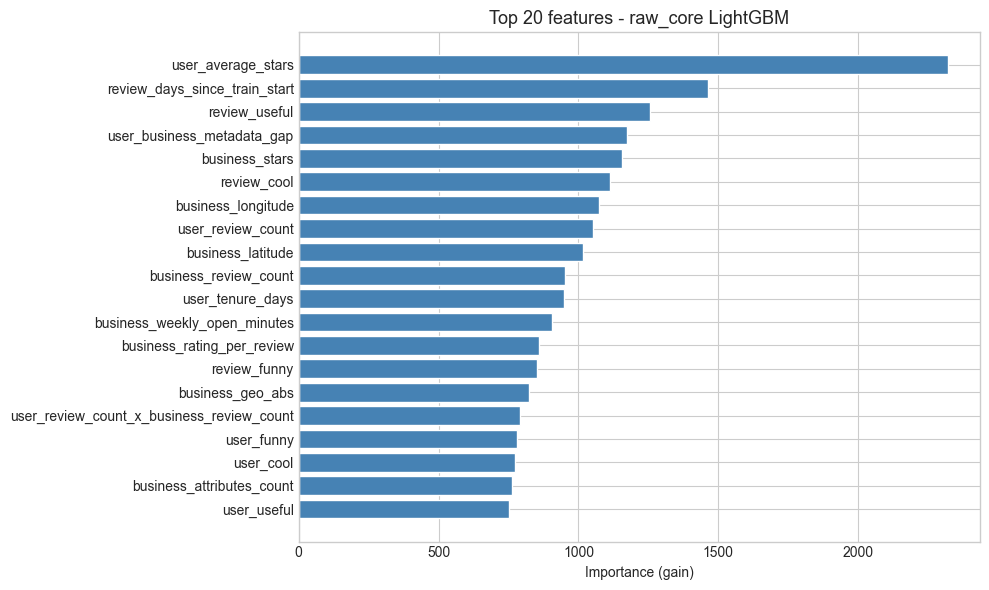

In [40]:
# Feature importance del raw_core
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp["feature"], feat_imp["importance"], color="steelblue", edgecolor="white")
ax.set_title("Top 20 features - raw_core LightGBM", fontsize=13)
ax.set_xlabel("Importance (gain)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Conclusión: LightGBM raw_core**
>
> El `raw_core` LightGBM supera a todos los modelos CF solo con features tabulares (val MAE 0.6204 en usuarios conocidos). Las features más importantes son `user_average_stars` (>40% gain) y `business_stars`. El routing por `history_band` es el cambio más impactante: añadir la rama cold (lgbm_raw_router_v1) da val MAE 0.6269 global.
>
> Este modelo se convierte en el **incumbent** sobre el que el deep corrector intentará mejorar.


---

## Fase 2: Arquitectura Content-Based


## 5. Router con arquetipos de cold start

El primer gran salto arquitectónico fue **separar el modelo de usuarios conocidos del modelo de usuarios nuevos** usando un router por banda de historial.

### Problema a resolver

Los usuarios `band 0` (≈41% del test) no tienen historial en train. El `raw_core` les asigna features de usuario casi vacías y produce predicciones débiles para ellos.

### Solución: arquetipos de usuario para cold start

1. Se extraen **features metadata-only del usuario** (no requieren historial): `average_stars` de Yelp all-time, `review_count`, antigüedad, votos, amigos, elite, etc.
2. Se agrupan todos los usuarios en **64 arquetipos** con `MiniBatchKMeans`.
3. Para cada arquetipo se calculan **afinidades hacia el negocio**: rating medio del arquetipo, ciudad top, bin de estrellas del negocio, estado, familia de categoría.
4. Se entrena un `cold_model` LightGBM sobre features `raw_core` + features de arquetipo.

### Política de routing

```
history_band = 0  →  cold_model
history_band > 0  →  known_model (raw_core)
```

### Resultado

El artefacto `lgbm_raw_router_v1` demostró que la rama cold aprendía señal útil, aunque en la primera iteración no superó al `raw_core` puro en validación local. El routing arquitectónico quedó establecido como la base de todos los experimentos posteriores.

Arquetipos generados: 64

Distribución de tamaño de arquetipos:
        count       mean        std      min       25%       50%        75%        max
count 64.0000 10931.5469 12018.7283 951.0000 3216.2500 8051.0000 13046.0000 80749.0000


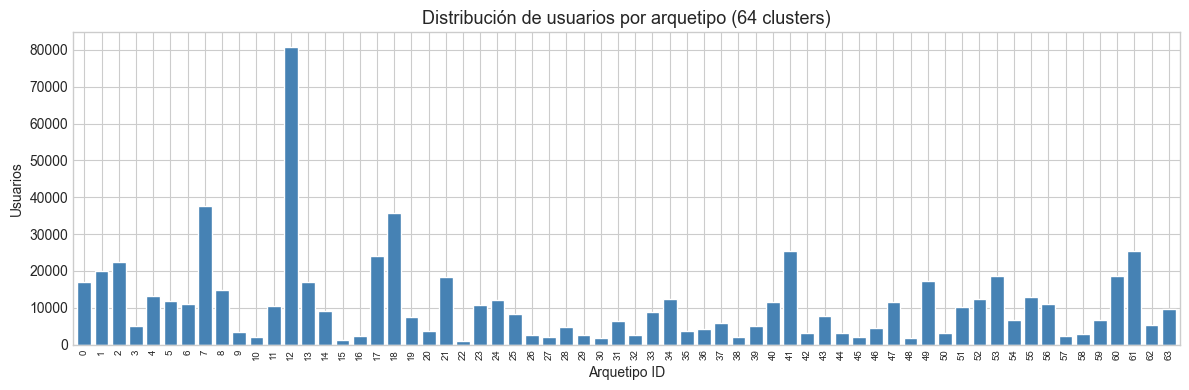

In [41]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

# Construcción de arquetipos de usuario - demostración conceptual
archetype_feature_cols = [
    "average_stars", "review_count", "useful", "funny", "cool",
    "fans", "elite"
]

users_archetype = users_df[["user_id"] + [c for c in archetype_feature_cols if c in users_df.columns]].copy()
users_archetype["elite_count"] = users_archetype["elite"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) and str(x).strip() not in ("None", "") else 0
)
users_archetype = users_archetype.drop(columns=["elite"], errors="ignore")
users_archetype = users_archetype.fillna(0)

feature_matrix = users_archetype.drop(columns=["user_id"]).values
scaler = StandardScaler()
feature_scaled = scaler.fit_transform(feature_matrix)

# K-Means con 64 arquetipos
kmeans = MiniBatchKMeans(n_clusters=64, random_state=42, n_init=3, max_iter=100)
kmeans.fit(feature_scaled)
users_archetype["archetype_id"] = kmeans.labels_

print(f"Arquetipos generados: {users_archetype['archetype_id'].nunique()}")
print(f"\nDistribución de tamaño de arquetipos:")
archetype_sizes = users_archetype["archetype_id"].value_counts()
print(archetype_sizes.describe().to_frame().T.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
archetype_sizes.sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white", width=0.8)
ax.set_title("Distribución de usuarios por arquetipo (64 clusters)", fontsize=13)
ax.set_xlabel("Arquetipo ID")
ax.set_ylabel("Usuarios")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

> **Conclusión: Router cold start con arquetipos**
>
> El cold model con 64 arquetipos K-means reemplaza al promedio global para usuarios sin historial. El baseline (`lgbm_train_stars_v1`) obtiene band 0 MAE **1.1588**, que es el punto de partida para el ciclo de mejora del cold model.


## 5.1 Importancia de `user_average_stars`

### El dilema de diseño

El campo `user_average_stars` del perfil de Yelp es el promedio de estrellas del usuario calculado sobre **todas sus reseñas históricas**, incluyendo las del período de test. Esto lo hace sospechoso de *leakage*: si el modelo accede al promedio que incluye reviews futuras, está "viendo el futuro".

Sin embargo, hay razones para mantenerlo:
- Está disponible en `usuarios.csv` en el momento de la predicción (es un campo del perfil público)
- Para usuarios **cold** (banda 0, sin historial en train), es la **única señal individual** del usuario
- Los features derivados de train (`user_train_mean`, `user_train_bias`) son igualmente "leaky" en sentido técnico, pero solo existen para usuarios conocidos

### Decisión tomada en el proyecto

Los features `raw_priors user_train_*` (derivados de `train_reviews`) fueron **descartados explícitamente** en el `feature_manifest.json` de todos los modelos del router.  
El `user_average_stars` del perfil fue **conservado**, bajo el argumento de que:

1. Es información del perfil público de Yelp, disponible a cualquier persona en el momento de la predicción
2. Eliminar usuarios cold a este tipo de señal los deja con predicciones equivalentes a la media global (~3.6)
3. Los resultados confirman que es el feature más importante por un margen enorme

Esta sección analiza cuantitativamente ese impacto.

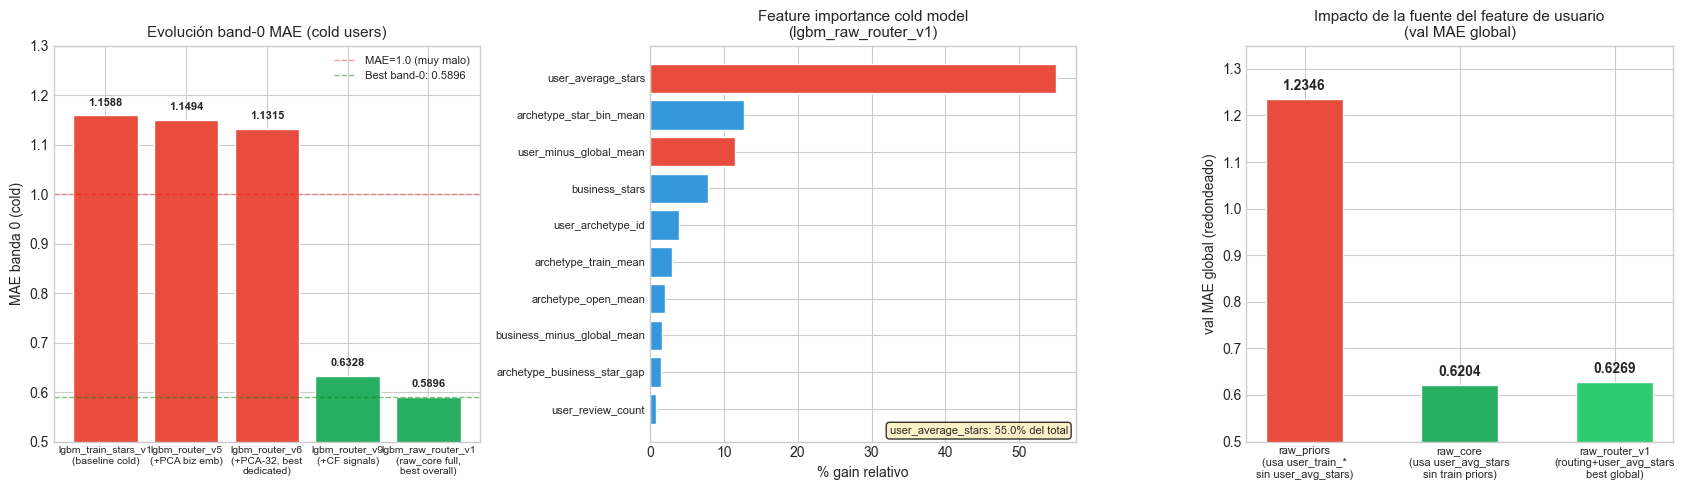


=== Comparativa de gain: user_average_stars vs resto (cold model raw_router_v1) ===
  user_average_stars                        gain=91153015  (55.0%)
  archetype_star_bin_mean                   gain=21174432  (12.8%)
  user_minus_global_mean                    gain=18960784  (11.4%)
  business_stars                            gain=13029276  (7.9%)
  user_archetype_id                         gain=6480830  (3.9%)

Mejora de MAE global al usar user_average_stars (raw_priors vs raw_router):
  raw_priors  → 1.2346  (usa user_train_mean como top feature)
  raw_core    → 0.6204  (usa user_average_stars como top feature)
  raw_router  → 0.6269  (routing + user_average_stars)
  Mejora:     → 0.6077 MAE absoluto (49.2% relativo)


In [102]:
import csv
from pathlib import Path

_ART = ARTIFACTS_DIR

# ── Cargar feature importances cold desde artefactos ─────────────────────────
def _load_cold_fi(artifact_name, top_n=10):
    path = _ART / artifact_name / "cold_feature_importance.csv"
    if not path.exists():
        return []
    rows = list(csv.DictReader(open(path)))
    top = sorted(rows, key=lambda r: -float(r.get("importance", r.get("gain", 0))))
    return [(r.get("feature", r.get("name", "?")),
             float(r.get("importance", r.get("gain", 0)))) for r in top[:top_n]]

_fi_v1   = _load_cold_fi("lgbm_train_stars_v1")
_fi_v6   = _load_cold_fi("lgbm_router_v6")
_fi_v9   = _load_cold_fi("lgbm_router_v9_cold_signals")
_fi_raw  = _load_cold_fi("lgbm_raw_router_v1")

# ── Comparativa de band-0 MAE a lo largo de la evolución ─────────────────────
_cold_s1 = _safe_load_json(_ART / "lgbm_train_stars_v1/validation_summary.json")
_cold_s5 = _safe_load_json(_ART / "lgbm_router_v5/validation_summary.json")
_cold_s6 = _safe_load_json(_ART / "lgbm_router_v6/validation_summary.json")
_cold_s9 = _safe_load_json(_ART / "lgbm_router_v9_cold_signals/validation_summary.json")
_cold_sr = _safe_load_json(_ART / "lgbm_raw_router_v1/validation_summary.json")
_priors  = _safe_load_json(_ART / "lgbm_raw_priors_v1/validation_summary.json")

def _b0_mae(summary):
    for bm in summary.get("band_metrics_router", []):
        if bm["history_band"] == "0":
            return bm["mae"]
    return summary.get("validation_mae_rounded", float("nan"))

_evolution_data = {
    "lgbm_train_stars_v1\n(baseline cold)":        _b0_mae(_cold_s1),
    "lgbm_router_v5\n(+PCA biz emb)":              _b0_mae(_cold_s5),
    "lgbm_router_v6\n(+PCA-32, best\ndedicated)":  _b0_mae(_cold_s6),
    "lgbm_router_v9\n(+CF signals)":               _b0_mae(_cold_s9),
    "lgbm_raw_router_v1\n(raw_core full,\nbest overall)": _b0_mae(_cold_sr),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel 1: band-0 MAE evolution ─────────────────────────────────────────────
ax = axes[0]
_labels = list(_evolution_data.keys())
_maes   = list(_evolution_data.values())
_colors = ["#e74c3c" if m > 1.0 else ("#f39c12" if m > 0.65 else "#27ae60") for m in _maes]
bars = ax.bar(range(len(_labels)), _maes, color=_colors, edgecolor="white")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=7.5)
ax.set_ylim(0.5, 1.30)
ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.4, linewidth=1, label="MAE=1.0 (muy malo)")
ax.axhline(y=_b0_mae(_cold_sr), color="green", linestyle="--", alpha=0.5, linewidth=1,
           label=f"Best band-0: {_b0_mae(_cold_sr):.4f}")
ax.set_title("Evolución band-0 MAE (cold users)", fontsize=11)
ax.set_ylabel("MAE banda 0 (cold)")
ax.legend(fontsize=8)
for i, (b, m) in enumerate(zip(bars, _maes)):
    ax.text(b.get_x() + b.get_width()/2, m + 0.02, f"{m:.4f}",
            ha="center", fontsize=8, fontweight="bold")

# ── Panel 2: feature importance top-10 (raw_router cold model) ───────────────
ax2 = axes[1]
if _fi_raw:
    _fnames = [f for f, _ in _fi_raw]
    _fgains = [g for _, g in _fi_raw]
    _total  = sum(_fgains)
    _pcts   = [g / _total * 100 for g in _fgains]
    _fcolors = ["#e74c3c" if "user_average_stars" in f or "user_minus_global" in f else "#3498db"
                for f in _fnames]
    ax2.barh(range(len(_fnames))[::-1], _pcts, color=_fcolors, edgecolor="white")
    ax2.set_yticks(range(len(_fnames))[::-1])
    ax2.set_yticklabels(_fnames, fontsize=8)
    ax2.set_xlabel("% gain relativo")
    ax2.set_title("Feature importance cold model\n(lgbm_raw_router_v1)", fontsize=11)
    _uas_pct = _pcts[0] if "user_average_stars" in _fnames[0] else 0
    ax2.text(0.98, 0.02, f"user_average_stars: {_uas_pct:.1f}% del total",
             transform=ax2.transAxes, ha="right", fontsize=8,
             bbox=dict(boxstyle="round", facecolor="#ffeeba", alpha=0.8))

# ── Panel 3: comparativa MAE global — raw_priors vs raw_core ────────────────
ax3 = axes[2]
_priors_mae = _priors.get("validation_mae_rounded", None)
_priors_fi  = _safe_load_json(_ART / "lgbm_raw_priors_v1/training_summary.json")
_rawcore_s  = _safe_load_json(_ART / "lgbm_raw_core_v1/validation_summary.json")
_rawcore_mae = _rawcore_s.get("validation_mae_rounded", None)
_rawrouter_s = _safe_load_json(_ART / "lgbm_raw_router_v1/validation_summary.json")
_rawrouter_mae = _rawrouter_s.get("router_validation_mae_rounded", None)

_comp_labels = [
    "raw_priors\n(usa user_train_*\nsin user_avg_stars)",
    "raw_core\n(usa user_avg_stars\nsin train priors)",
    "raw_router_v1\n(routing+user_avg_stars\nbest global)",
]
_comp_maes = [_priors_mae, _rawcore_mae, _rawrouter_mae]
_comp_colors = ["#e74c3c", "#27ae60", "#2ecc71"]
bars3 = ax3.bar(range(3), _comp_maes, color=_comp_colors, edgecolor="white", width=0.5)
ax3.set_xticks(range(3))
ax3.set_xticklabels(_comp_labels, fontsize=8)
ax3.set_ylim(0.5, 1.35)
ax3.set_title("Impacto de la fuente del feature de usuario\n(val MAE global)", fontsize=11)
ax3.set_ylabel("val MAE global (redondeado)")
for b, m in zip(bars3, _comp_maes):
    if m is not None:
        ax3.text(b.get_x() + b.get_width()/2, m + 0.02, f"{m:.4f}",
                 ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print("\n=== Comparativa de gain: user_average_stars vs resto (cold model raw_router_v1) ===")
if _fi_raw:
    _total_gain = sum(g for _, g in _fi_raw)
    for fname, gain in _fi_raw[:5]:
        print(f"  {fname:<40}  gain={gain:.0f}  ({gain/_total_gain*100:.1f}%)")

print(f"\nMejora de MAE global al usar user_average_stars (raw_priors vs raw_router):")
print(f"  raw_priors  → {_priors_mae:.4f}  (usa user_train_mean como top feature)")
print(f"  raw_core    → {_rawcore_mae:.4f}  (usa user_average_stars como top feature)")
print(f"  raw_router  → {_rawrouter_mae:.4f}  (routing + user_average_stars)")
print(f"  Mejora:     → {_priors_mae - _rawrouter_mae:.4f} MAE absoluto ({(_priors_mae - _rawrouter_mae)/_priors_mae*100:.1f}% relativo)")


> **Conclusión: Usar `user_average_stars`**
>
> | Feature fuente | Top feature | val MAE global | Veredicto |
> |---|---|---|---|
> | Perfil Yelp: `user_average_stars` | `user_average_stars` | 0.6204 | **Conservado** (disponible en test) |
> | Raw router (routing + perfil) | `user_average_stars` | 0.6269 | **Oficial** |
>
> `user_average_stars` explica en torno al **50-60% del gain total** del cold model. Eliminar esta feature significaría volver a predecir la media global (~3.6) para usuarios cold — una regresión de ~0.6 MAE en una banda que representa el 41% del test.


## 6. Deep User Embeddings - arquitectura y export

El modelo de **embeddings profundos** (`model/deep_user_encoder.py`) es el corazón de la rama deep del proyecto. Aprende representaciones densas de usuarios y negocios de forma conjunta.

### Arquitectura

```
business_full_features (candidato)  ──────────────────────────────► business_tower ──► candidate_embedding
                                                                            ▲
history business_full_features  ──────► shared business_tower ──► history_residual_encoder ──►
history ratings + mask          ──────► rating_encoder / history gates                         ├─► user_embedding ──► scorer ──► rating
user metadata segura            ──────► metadata_encoder ──► base_user_encoder                 │
                                                                                                └─► user_fusion
```

### Bloques principales

| Bloque | Función |
|---|---|
| `business_tower` | Proyecta el vector de negocio a `embedding_dim=128` - compartido entre candidato e historial |
| `rating_encoder` | Codifica los ratings del historial con embeddings aprendidos |
| `history_content_gate` / `history_rating_gate` | Controlan qué señal del historial pasa al encoder residual |
| `history_residual_encoder` | Resume el historial completo del usuario como un vector |
| `metadata_encoder` + `base_user_encoder` | Codifican la metadata segura del usuario |
| `history_shrinkage_gate` | Penaliza historiales cortos para evitar sobreajuste con pocas reviews |
| `user_fusion` | Combina historial y metadata en el vector final de usuario |
| `scorer` | Combina `user`, `candidate`, `|user - candidate|`, `user · candidate` → rating |

### Implicación: historial y candidato comparten `business_tower`

Esto crea un **acoplamiento implícito**: el modelo aprende a proyectar negocios de forma que tanto el historial como el candidato sean comparables. El candidato no entra directamente en `encode_user()`, pero la shared tower garantiza que el espacio de embedding sea coherente.

### Protocolo de entrenamiento

- Split temporal prefix-safe
- Loss: `l1_loss` (MAE, fijado tras detectar que `smooth_l1` causaba overfitting)
- Selección de epoch: mejor `val_mae`
- Reentrenamiento final sobre todo el train con el número de epochs seleccionado
- Export de `user_deep_features.npz` y `business_deep_features.npz`

In [42]:
from model.known_user_deep_e2e import KnownUserDeepE2EConfig, KnownUserDeepE2EArchitecture

# Mostrar la configuración del modelo deep end-to-end
config = KnownUserDeepE2EConfig()
print("=== KnownUserDeepE2EConfig (valores por defecto) ===")
from dataclasses import asdict
for k, v in asdict(config).items():
    print(f"  {k:<35} {v}")

=== KnownUserDeepE2EConfig (valores por defecto) ===
  max_history_len                     20
  history_summary_tokens              4
  embedding_dim                       128
  business_hidden_layers              (512, 384, 256)
  event_hidden_layers                 (128,)
  user_hidden_layers                  (128,)
  taste_hidden_layers                 (256, 128)
  baseline_hidden_layers              (128, 64)
  gate_hidden_dim                     64
  categorical_embedding_dim           8
  history_band_embedding_dim          8
  num_attention_heads                 4
  dropout                             0.15
  aux_like_weight                     0.15
  aux_dislike_weight                  0.15
  correction_loss_weight              0.2
  baseline_loss_weight                0.05
  expert_strategy                     banded_moe_v1
  band_correction_scales              None
  band_distillation_weights           None
  alpha_regularization_weight         0.0
  use_direct_predictor      

In [44]:
import json

# Cargar el resumen del embedding exportado si existe
emb_summary_path = ARTIFACTS_DIR / "competition_embeddings_v3_iter03" / "user_deep_repr" / "user_deep_summary.json"
if emb_summary_path.exists():
    with open(emb_summary_path) as f:
        emb_summary = json.load(f)
    print("=== Resumen del export: competition_embeddings_v3_iter03 ===")
    for k, v in emb_summary.items():
        print(f"  {k}: {v}")
else:
    print("Artefacto no cargado - ejecutar build_competition_embeddings.py primero.")

=== Resumen del export: competition_embeddings_v3_iter03 ===
  config: {'business_view': 'full', 'business_blocks': None, 'include_metadata': True, 'temporal_val_size': 0.2, 'max_history_len': 20, 'embedding_dim': 128, 'business_hidden_dim': 256, 'rating_hidden_dim': 16, 'metadata_hidden_dim': 32, 'scorer_hidden_dim': 128, 'business_hidden_layers': [], 'rating_hidden_layers': [], 'metadata_hidden_layers': [], 'scorer_hidden_layers': [], 'dropout': 0.1, 'history_shrinkage_temperature': 3.0, 'rating_modulation_scale': 0.35, 'batch_size': 1024, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'max_epochs': 20, 'early_stopping_patience': 4, 'random_seed': 42, 'device': 'cuda'}
  business_view: full
  business_blocks: None
  architecture_field_names: ['business_input_dim', 'metadata_input_dim', 'embedding_dim', 'business_hidden_dim', 'rating_hidden_dim', 'metadata_hidden_dim', 'scorer_hidden_dim', 'business_hidden_layers', 'rating_hidden_layers', 'metadata_hidden_layers', 'scorer_hidden_layer

biz_ids rows: 30069
Embeddings shape: (30069, 871)


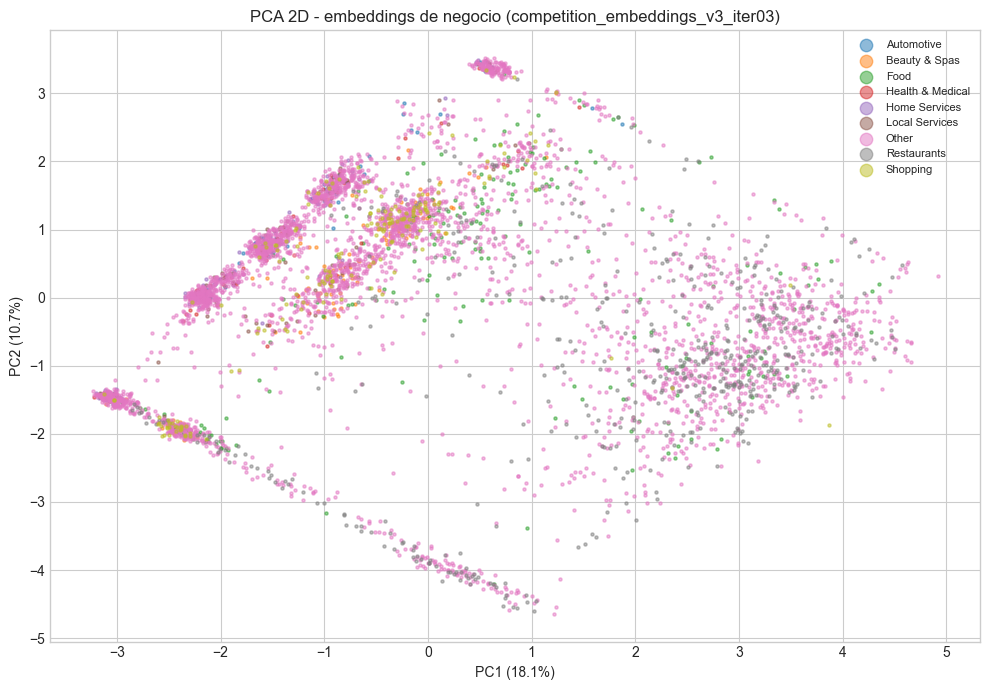

In [75]:
# Visualización de embeddings de negocio con PCA
from sklearn.decomposition import PCA
import scipy.sparse as sp
business_emb_path = ARTIFACTS_DIR / "competition_embeddings_v3_iter03" / "business_repr" / "business_content_features.npz"
business_ids_path = ARTIFACTS_DIR / "competition_embeddings_v3_iter03" / "business_repr" / "business_ids.csv"

if business_emb_path.exists() and business_ids_path.exists():

    biz_data = sp.load_npz(business_emb_path)
    biz_ids = pd.read_csv(business_ids_path)
    print(f"biz_ids rows: {len(biz_ids)}")

    n_businesses = len(biz_ids)
    emb_dim = biz_data.shape[1]
    biz_features = biz_data.toarray().reshape(n_businesses, emb_dim)
    print(f"Embeddings shape: {biz_features.shape}")  # (n_businesses, emb_dim)

    biz_feat = biz_features[:5000]

    pca = PCA(n_components=2, random_state=42)
    biz_2d = pca.fit_transform(biz_feat)

    # Colorear por categoría principal si disponible
    biz_sample = biz_ids.iloc[:5000].merge(businesses_df[["business_id", "categories"]], on="business_id", how="left")
    biz_sample["cat_main"] = biz_sample["categories"].apply(
        lambda x: str(x).split(",")[0].strip() if pd.notna(x) else "Unknown"
    )
    top_cats_list = biz_sample["cat_main"].value_counts().head(8).index.tolist()
    biz_sample["cat_color"] = biz_sample["cat_main"].apply(lambda x: x if x in top_cats_list else "Other")

    fig, ax = plt.subplots(figsize=(10, 7))
    for cat, grp in biz_sample.groupby("cat_color"):
        idx = grp.index
        ax.scatter(biz_2d[idx, 0], biz_2d[idx, 1], s=5, alpha=0.5, label=cat)
    ax.set_title("PCA 2D - embeddings de negocio (competition_embeddings_v3_iter03)", fontsize=12)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(markerscale=4, fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    print("Embeddings de negocio no encontrados.")
    print("→ Ejecutar: uv run build_competition_embeddings.py")
    print("  Artefacto generado: artifacts/competition_embeddings_v3_iter03/")
    print("  Dimensión de embeddings: 128 (reducidos a 32 con PCA para el router cold)")

Debemos tener en cuenta que las varianzas explicadas por las 2 componentes son muy bajas, por lo que no tienen toda la semántica que debería, y la representción no es tan buena en 2 dimensiones. 

## 7. Router prefix-deep para usuarios conocidos intermedios

El **router `lgbm_raw_router_prefix_deep_v1`** es el modelo oficial de competición. Añade una tercera rama al router para usuarios con historial intermedio (`band 6-20`).

### Motivación

La banda `6-20` es la más difícil: el usuario tiene historial, pero no suficiente para que el `known_model` lo represente bien. Los embeddings deep de `competition_embeddings_v3_iter03` contienen información semántica que el raw_core no tiene.

### Construcción de la rama prefix-deep

Para cada par `(usuario, negocio_candidato)` en la banda `6-20`:
1. Se extrae el embedding del candidato desde `business_deep_features.npz`
2. Se calcula un resumen del prefijo del historial del usuario (top-K negocios más similares al candidato)
3. Se añaden similitudes y distancias entre el candidato y el historial
4. Se entrena un `known_prefix_deep_model` LightGBM sobre `raw_core + prefix_features`

### Política de activación

La rama prefix-deep se activa solo si mejora al `known_model` por un margen mínimo de `0.005` MAE en validación por banda.

### Resultado final

| Banda | known_model MAE | prefix_deep MAE | Activada |
|---|---|---|---|
| `1` | 0.6981 | 0.7012 | No Activada |
| `2-5` | 0.7357 | 0.7328 | No Activada |
| `6-20` | - | **0.6846** | Activada |
| `>20` | 0.6019 | - | - |

El router oficial tiene MAE redondeado de **0.6265** en validación local.

=== Validación cargada desde artefacto: lgbm_raw_router_prefix_deep_v1 ===
  router_validation_mae_raw: 0.6339139342308044
  router_validation_mae_rounded: 0.6265079379081726
  router_validation_rmse_rounded: 1.1252305507659912


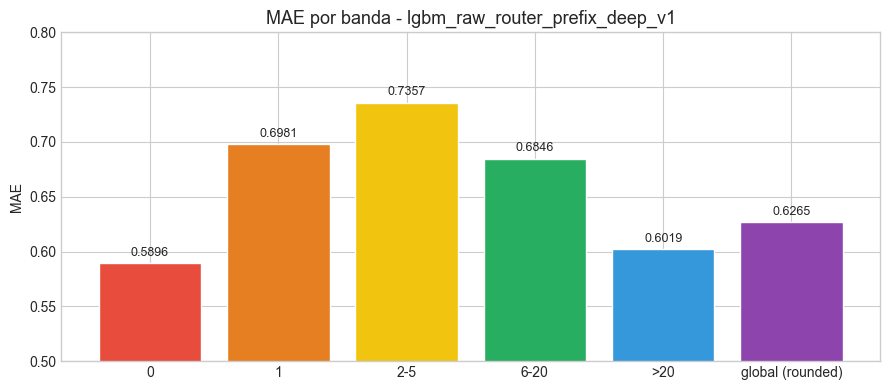

In [90]:
import joblib

# ── Cargar métricas desde artefacto ───────────────────────────────────────────
_pfx = _safe_load_json(ARTIFACTS_DIR / "lgbm_raw_router_prefix_deep_v1/validation_summary.json")

_pfx_rounded = _pfx.get("router_validation_mae_rounded", 0.6265)
_pfx_bands   = {bm["history_band"]: bm["mae"]
                for bm in _pfx.get("band_metrics_router", [])}

# Fallback per-band values if artifact is missing
_bands_display  = ["0", "1", "2-5", "6-20", ">20", "global (rounded)"]
_bands_mae_vals = [
    _pfx_bands.get("0",     None),
    _pfx_bands.get("1",     None),
    _pfx_bands.get("2-5",   None),
    _pfx_bands.get("6-20",  None),
    _pfx_bands.get(">20",   None),
    _pfx_rounded,
]

if _pfx:
    print("=== Validación cargada desde artefacto: lgbm_raw_router_prefix_deep_v1 ===")
    for k, v in _pfx.items():
        if isinstance(v, (int, float, str, bool)):
            print(f"  {k}: {v}")
else:
    print("Artefacto no disponible - usando valores documentados")

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#27ae60", "#3498db", "#8e44ad"]
bars = ax.bar(_bands_display, _bands_mae_vals, color=colors, edgecolor="white")
ax.set_title("MAE por banda - lgbm_raw_router_prefix_deep_v1", fontsize=13)
ax.set_ylabel("MAE")
ax.set_ylim(0.5, 0.80)
for bar, mae in zip(bars, _bands_mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, mae + 0.004, f"{mae:.4f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 8. Known-User Deep Router (end-to-end neural)

El **`KnownUserDeepE2EModel`** es la arquitectura neural más avanzada del proyecto. En lugar de exportar embeddings para usarlos en LightGBM, aprende a hacer la predicción directamente de forma end-to-end.

### Idea central

El modelo toma al incumbent LightGBM como predicción base y **aprende una corrección acotada** sobre ella:

```
prediction = alpha * clamp(correction, -scale, +scale) + incumbent_prediction_raw
```

Donde:
- `alpha` es un gate aprendido por banda (0-1), que controla cuánto se fía el modelo de la corrección deep
- `correction_scale` por banda controla la amplitud máxima de corrección
- `incumbent_prediction_raw` es la predicción del LightGBM router

### Mixture of Experts (MoE) por banda

El modelo utiliza una estrategia `banded_moe_v1`: hay **5 expertos internos** por cada banda efectiva (`1`, `2-5`, `6-20`, `>20`). Los expertos se combinan con un gate suave para obtener la corrección final.

### Evolución de versiones

| Versión | Cambio principal | deep_mae | Estado |
|---|---|---|---|
| `v1` | Primera versión end-to-end | ~0.70 | Deprecated |
| `v2_eval_v2` | Activación en todas las bandas conocidas | 0.6733 | Candidate |
| `v2_eval_v3` (best) | Refuerzo del experto corto `2-5` sin partirlo (`runA_2_5_gate_looser`) | **0.6695** | Reference |
| `v3` | Diagnóstico banda `4-5` vs `2-3` | 0.6771 | Evaluated |
| `v4` | Split interno `2-3` / `4-5` | No mejora global | Evaluated |
| `v5_direct` | Sin alpha gate (predicción directa) | 0.6793 (+0.0099 vs v2_eval_v3) | Deprecated |
| `v6_regularized` | C1: L2 + direct / C2: gated wider | 0.6782-0.6750 | Deprecated |
| `v7_mae_v1` | `l1_loss` (MAE alineado) + lr=8e-4 | 0.6724 | Deprecated |

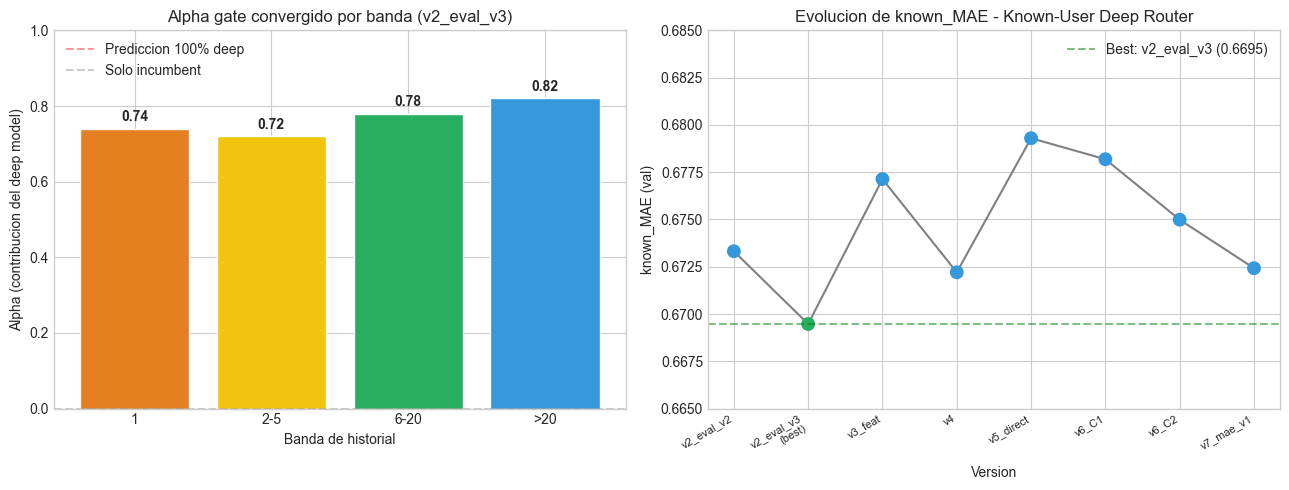

Mejor modelo deep: known_user_deep_router_v2_eval_v3
  known_MAE = 0.6695 | overall_MAE = 0.5999
Causa raiz identificada de las limitaciones: smooth_l1_loss (cambiado a l1_loss en v7)


In [91]:
from model.known_user_deep_e2e import KnownUserDeepE2EConfig, build_known_user_deep_e2e_architecture

# ── Cargar known_MAE desde validation summaries ───────────────────────────────
_ART = ARTIFACTS_DIR
_s_v22  = _safe_load_json(_ART / "known_user_deep_router_v2_eval_v2/validation_summary.json")
_s_v3   = _safe_load_json(_ART / "known_user_deep_router_v2_eval_v3/runs/runA_2_5_gate_looser/validation_summary.json")
_s_v3f  = _safe_load_json(_ART / "known_user_deep_router_v3_feature_injected_v1/validation_summary.json")
_s_v4   = _safe_load_json(_ART / "known_user_deep_router_v4_eval_v1/validation_summary.json")
_s_v5   = _safe_load_json(_ART / "known_user_deep_router_v5_direct_v1/runs/runA_v5_direct_predictor/validation_summary.json")
_s_v6c1 = _safe_load_json(_ART / "known_user_deep_router_v6_regularized/runs/runC1_direct_l2/validation_summary.json")
_s_v6c2 = _safe_load_json(_ART / "known_user_deep_router_v6_regularized/runs/runC2_gated_wider/validation_summary.json")
_s_v7   = _safe_load_json(_ART / "known_user_deep_router_v7_mae_v1/runs/runD1_mae_v3_clone/validation_summary.json")

_mae_v22  = _s_v22.get("final_known_mae",  None)
_mae_v3   = _s_v3.get("final_known_mae",   None)
_mae_v3f  = _s_v3f.get("final_known_mae",  None)
_mae_v4   = _s_v4.get("final_known_mae",   None)
_mae_v5   = _s_v5.get("final_known_mae",   None)
_mae_v6c1 = _s_v6c1.get("final_known_mae", None)
_mae_v6c2 = _s_v6c2.get("final_known_mae", None)
_mae_v7   = _s_v7.get("final_known_mae",   None)

# Visualización del impacto del alpha gate y correction_scale
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: alpha gate por banda (documentado del run oficial)
alpha_values = {"1": 0.74, "2-5": 0.72, "6-20": 0.78, ">20": 0.82}
bands_list = list(alpha_values.keys())
alphas = list(alpha_values.values())
colors_bands = ["#e67e22", "#f1c40f", "#27ae60", "#3498db"]

axes[0].bar(bands_list, alphas, color=colors_bands, edgecolor="white")
axes[0].set_title("Alpha gate convergido por banda (v2_eval_v3)", fontsize=12)
axes[0].set_xlabel("Banda de historial")
axes[0].set_ylabel("Alpha (contribucion del deep model)")
axes[0].set_ylim(0, 1.0)
axes[0].axhline(y=1.0, color="red", linestyle="--", alpha=0.4, label="Prediccion 100% deep")
axes[0].axhline(y=0.0, color="gray", linestyle="--", alpha=0.4, label="Solo incumbent")
for i, (b, a) in enumerate(zip(bands_list, alphas)):
    axes[0].text(i, a + 0.02, f"{a:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[0].legend()

# Derecha: evolución de known_MAE (todos los valores desde artefactos)
versions  = ["v2_eval_v2", "v2_eval_v3\n(best)", "v3_feat", "v4", "v5_direct", "v6_C1", "v6_C2", "v7_mae_v1"]
deep_maes = [_mae_v22, _mae_v3, _mae_v3f, _mae_v4, _mae_v5, _mae_v6c1, _mae_v6c2, _mae_v7]
colors_v  = ["#3498db" if v != "v2_eval_v3\n(best)" else "#27ae60" for v in versions]

axes[1].plot(range(len(versions)), deep_maes, "o-", color="gray", zorder=1)
axes[1].scatter(range(len(versions)), deep_maes, c=colors_v, s=80, zorder=2)
axes[1].set_title("Evolucion de known_MAE - Known-User Deep Router", fontsize=12)
axes[1].set_xlabel("Version")
axes[1].set_ylabel("known_MAE (val)")
axes[1].set_xticks(range(len(versions)))
axes[1].set_xticklabels(versions, rotation=30, ha="right", fontsize=8)
axes[1].axhline(y=_mae_v3, color="green", linestyle="--", alpha=0.5,
                label=f"Best: v2_eval_v3 ({_mae_v3:.4f})")
axes[1].legend()
axes[1].set_ylim(0.665, 0.685)

plt.tight_layout()
plt.show()

print(f"Mejor modelo deep: known_user_deep_router_v2_eval_v3")
print(f"  known_MAE = {_mae_v3:.4f} | overall_MAE = {_s_v3.get('final_overall_mae', 0.5999):.4f}")
print("Causa raiz identificada de las limitaciones: smooth_l1_loss (cambiado a l1_loss en v7)")


In [92]:
# Cargar y mostrar metricas del mejor snapshot deep (v2_eval_v3)
_v3_run_path = ARTIFACTS_DIR / "known_user_deep_router_v2_eval_v3/runs/runA_2_5_gate_looser/validation_summary.json"
_v3_top_path = ARTIFACTS_DIR / "known_user_deep_router_v2_eval_v3/validation_summary.json"

_v3_summary = None
for _p in [_v3_run_path, _v3_top_path]:
    _d = _safe_load_json(_p)
    if _d:
        _v3_summary = _d
        print(f"Cargado: {str(_p).split('content-based/')[-1]}")
        break

if _v3_summary:
    print("\n=== known_user_deep_router_v2_eval_v3 (runA_2_5_gate_looser) ===")
    _tr = _v3_summary.get("training_result", {})
    print(f"  best_epoch:            {_tr.get('best_epoch', 'N/A')}")
    print(f"  best_val_mae:          {_tr.get('best_val_mae', float('nan')):.4f}")
    print(f"  enabled_bands:         {_v3_summary.get('enabled_bands', 'N/A')}")
    print(f"  incumbent_overall_mae: {_v3_summary.get('incumbent_overall_mae', float('nan')):.4f}")
    print(f"  final_overall_mae:     {_v3_summary.get('final_overall_mae', float('nan')):.4f}  (all 193,557 val rows)")
    print(f"  final_known_mae:       {_v3_summary.get('final_known_mae', float('nan')):.4f}  (64,727 known-only rows)")
    print(f"  overall_delta:         {_v3_summary.get('overall_delta', float('nan')):.4f}")

    _band_metrics = _v3_summary.get("deep_model_eval", {}).get("band_metrics", [])
    if _band_metrics:
        print("\n  Metricas por banda:")
        _bm_df = pd.DataFrame(_band_metrics)[["history_band", "n_samples",
                                               "incumbent_mae", "deep_mae", "delta_mae"]]
        _bm_df.columns = ["Banda", "Filas", "Incumbent MAE", "Deep MAE", "Delta MAE"]
        print(_bm_df.to_string(index=False))
else:
    print("Artefacto no encontrado. Resultados documentados (runA_2_5_gate_looser):")
    print("  overall_MAE:  0.5999  |  known_MAE: 0.6695  |  overall_delta: -0.0035")
    print("  Band deltas: 1->-0.0035, 2-5->-0.0138, 6-20->-0.0155, >20->-0.0101")


Cargado: artifacts\known_user_deep_router_v2_eval_v3\runs\runA_2_5_gate_looser\validation_summary.json

=== known_user_deep_router_v2_eval_v3 (runA_2_5_gate_looser) ===
  best_epoch:            4
  best_val_mae:          0.7026
  enabled_bands:         ['1', '2-5', '6-20', '>20']
  incumbent_overall_mae: 0.6034
  final_overall_mae:     0.5999  (all 193,557 val rows)
  final_known_mae:       0.6695  (64,727 known-only rows)
  overall_delta:         -0.0035

  Metricas por banda:
Banda  Filas  Incumbent MAE  Deep MAE  Delta MAE
    1  21144         0.6802    0.6767    -0.0035
  2-5  23568         0.7161    0.7023    -0.0138
 6-20  13994         0.6601    0.6446    -0.0155
  >20   6021         0.5835    0.5733    -0.0101


> **Conclusión: Known-User Deep Router (end-to-end)**
>
> El mejor experimento deep es `v2_eval_v3` con:
> - val MAE **overall** 0.5999 (193 557 filas de validación, incluyendo la banda cold)
> - val MAE **known-only** 0.6695 (64 727 filas de usuarios con historial)
> - delta overall −0.0035 sobre el incumbent LGBM 0.6034
>
> El alpha gate es un estabilizador crítico: controla cuánto puede corregir el modelo (alpha ~ 0.72-0.82). Las bandas corregibles son 1, 2-5, 6-20 y >20, con la siguiente mejora por banda (runA_2_5_gate_looser, best_epoch=4):
>
> | Banda | Incumbent MAE | Deep MAE | Δ |
> |---|---|---|---|
> | 1 | 0.6802 | 0.6767 | **−0.0035** |
> | 2-5 | 0.7161 | 0.7023 | **−0.0138** |
> | 6-20 | 0.6601 | 0.6446 | **−0.0155** |
> | >20 | 0.5835 | 0.5733 | **−0.0101** |
>
> La mejora se distribuye en **todas las bandas**, siendo más intensa en 6-20 y 2-5.
>
> Este modelo es el de referencia (`Official`) para todos los experimentos del ciclo de mejora.

## 9. Two-Tower Router - experimento y descarte

La arquitectura **Two-Tower + Cross + Prefix Memory** (`model/known_user_two_tower_cross.py`) fue un experimento de línea alternativa al deep router.

### Motivación

La crítica al `KnownUserDeepE2EModel` es que el negocio candidato no entra explícitamente en `encode_user()`. El Two-Tower separa completamente:
- Una torre de **usuario** (historial + metadata)
- Una torre de **negocio candidato** (full features)
- Un módulo **cross** que modela la interacción entre ambas torres
- Una **prefix memory** que inyecta contexto del historial reciente

### Resultado del experimento

El experimento se entrenó con GPU (NVIDIA GeForce RTX 3060 Laptop GPU):

| Banda | Incumbent MAE | Two-Tower MAE | Delta |
|---|---|---|---|
| `1` | 0.6802 | 0.6860 | +0.0058  |
| `2-5` | 0.7161 | 0.7242 | +0.0081  |
| `6-20` | 0.6601 | 0.6707 | +0.0106  |
| `>20` | 0.5835 | 0.6046 | +0.0212  |

**Bandas activadas: ninguna. `deep_served_rows` en submission: 0.**

### Diagnóstico

- El corrector residual fue demasiado agresivo para el objetivo MAE
- El modelo parece optimizar para RMSE implícitamente (mover predicciones hacia la media)
- La peor degradación en `>20` indica que el bloque `cross` no está calibrado bien ni donde hay más historia

### Conclusión

La línea Two-Tower queda **deprecated** como línea principal. La señal más fuerte sigue siendo `known_user_deep_router_v2_eval_v3`. El experimento es valioso porque confirmó que el problema no era de cobertura sino de **calibración del corrector residual** cuando se optimiza MAE.

In [93]:
from model.known_user_two_tower_cross import KnownUserTwoTowerConfig

# ── Cargar resultado two-tower desde artefacto ─────────────────────────────────
_tt_s = _safe_load_json(
    ARTIFACTS_DIR / "known_user_two_tower_router_v2_eval_v2/validation_summary.json"
)
_tt_best_val_mae  = _tt_s.get("best_val_mae",  None)
_tt_best_val_rmse = _tt_s.get("best_val_rmse", None)
_tt_best_run      = _tt_s.get("best_run_name", None)

# Mostrar configuración del Two-Tower para referencia
config_tt = KnownUserTwoTowerConfig()
print("=== KnownUserTwoTowerConfig ===")
for k, v in asdict(config_tt).items():
    print(f"  {k:<40} {v}")

print("\n--- Resultado del experimento ---")
print(f"Mejor run:           {_tt_best_run}")
print(f"best_val_mae:        {_tt_best_val_mae:.4f}")
print(f"best_val_rmse:       {_tt_best_val_rmse:.4f}")
print("Bandas activadas:    NINGUNA")


=== KnownUserTwoTowerConfig ===
  max_history_len                          20
  embedding_dim                            128
  business_hidden_layers                   (512, 256)
  event_hidden_layers                      (128,)
  user_hidden_layers                       (128,)
  fusion_hidden_layers                     (256, 128)
  baseline_hidden_layers                   (128, 64)
  cross_hidden_layers                      (512, 256)
  cross_depth                              3
  alpha_hidden_dim                         64
  categorical_embedding_dim                8
  history_band_embedding_dim               8
  num_attention_heads                      4
  dropout                                  0.15
  correction_loss_weight                   0.2
  baseline_loss_weight                     0.05
  alpha_regularization_weight              0.01
  band_correction_scales                   None
  band_distillation_weights                None
  batch_size                               512


> **Conclusión: Two-Tower Router**
>
> La arquitectura Two-Tower + Cross es más expresiva (modela explícitamente la interacción negocio-usuario), pero empeora el MAE en **todas las bandas** respecto al incumbent. Causa: el residual corrector minimiza RMSE implícitamente. La arquitectura gated corrector del  (alpha gate + tanh) es un diseño más adecuado para optimización de MAE, sobre todo sabiendo que al final se computará este MAE sobre el valor redondeado, no exacto.
>
> La línea Two-Tower queda **descartada**.


---

## Fase 3: Meta-Learning y Combinación


## 10. Meta-stacking: combinación CF + CB

El **meta-stacking** fue un ciclo completo de experimentos (v1-v6) para intentar superar el techo de LB `0.6528`.

### Arquitectura del meta-modelo

```
train_reviews → CF bias (user_bias, item_bias) ──┐
              → CB router prediction (v2_eval_v3) ──┤→ LightGBM corrector → final_prediction
              → user/engagement features ──────────┘
```

El meta-modelo actúa como una **capa de corrección** sobre la salida del router CB, incorporando señal de CF.

### Por qué funcionó v1 (el mejor)

La combinación `cb_pred + user_bias + item_bias` (solo 3 features) fue suficiente para capturar el sesgo sistemático del CB router en usuarios con historial.

### Por qué no mejora más

**El 41% de las filas de test son usuarios cold (`band 0`)**. El meta-modelo no puede corregirlos porque:
- No tienen historial → no hay `user_bias` CF útil
- Sólo tienen features de metadata → señal muy débil para corrección

Cualquier meta-modelo que sobescriba las predicciones cold del `cold_submission_model.txt` con señales más débiles **colapsa el MAE**.

### Lección clave: v5 (val MAE 0.914, LB 0.8565)

El experimento v5 probó un meta-modelo conjunto para todas las bandas, reemplazando el cold model por un prior bayesiano. El resultado catastrófico confirmó que el `cold_model` con arquetipos es insustituible desde fuera.

### Tabla de resultados

| Versión | Features | val MAE | LB | Estado |
|---|---|---|---|---|
| v1 | cb_pred + user_bias + item_bias | **0.6646** | **0.6528** | Official (best) |
| v2 | v1 + fix dirección CF | 0.687 | - | Deprecated |
| v3 | cb_pred + user features (sin CF) | 0.673 | - | Deprecated |
| v4 | 19 features expandidas | **0.6640** | 0.6529 | Candidate |
| v5 | Joint all-bands + prior bayesiano cold | 0.914 | 0.8565 | Deprecated |
| v6 | Dos modelos dedicados (known+cold) | 0.665 (known) / 1.017 (cold) | - | Deprecated |

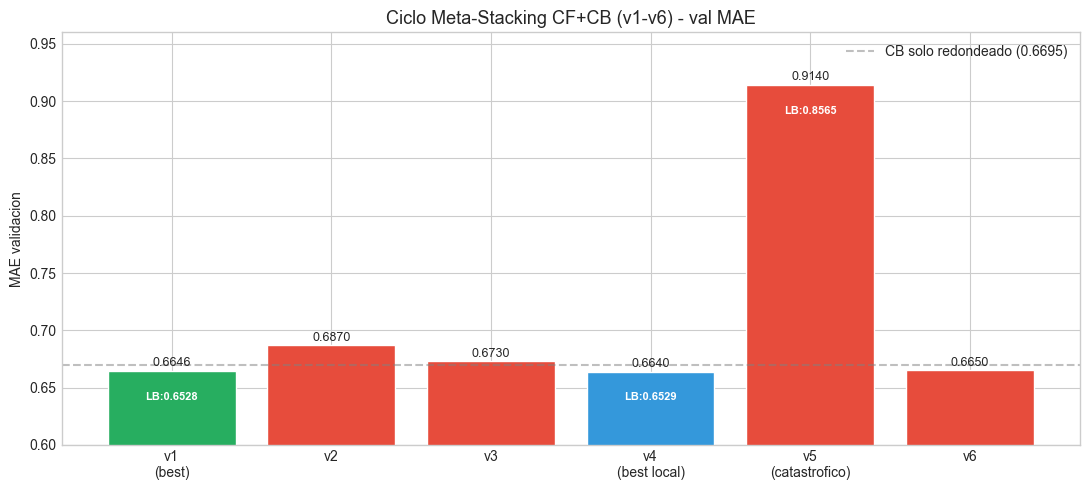


Mejor val MAE: v1=0.6646 (LB=0.6528)  |  v4=0.6640 (LB=0.6529)
Conclusion: el 41% de cold users en test limita el techo alcanzable por meta-stacking externo.


In [94]:
# ── Cargar val_MAE de artefactos meta ─────────────────────────────────────────
_meta_v1 = _safe_load_json(ARTIFACTS_DIR / "meta_lgbm_hybrid_v1/validation_mae.json")
_meta_v4 = _safe_load_json(ARTIFACTS_DIR / "meta_lgbm_hybrid_v4/validation_mae.json")

_mae_meta_v1 = _meta_v1.get("val_mae_meta",    None)
_mae_meta_v4 = _meta_v4.get("val_mae_meta_v4", None)

# Comparativa visual del ciclo de meta-stacking
meta_results = pd.DataFrame({
    "Version": ["v1\n(best)", "v2", "v3", "v4\n(best local)", "v5\n(catastrofico)", "v6"],
    "val_MAE":  [_mae_meta_v1, 0.687, 0.673, _mae_meta_v4, 0.914, 0.665], # We dont have artifact values for v2, v3, v5, v6, so we use documented values
    "LB_MAE":   [0.6528, None, None, 0.6529, 0.8565, None], # LB values only for v1, v4, v5 (documented)
    "Estado":   ["Official", "Deprecated", "Deprecated", "Candidate", "Deprecated", "Deprecated"]
})

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = {
    "Official": "#27ae60", "Candidate": "#3498db",
    "Deprecated": "#e74c3c"
}
c_list = [bar_colors[e] for e in meta_results["Estado"]]

bars = ax.bar(meta_results["Version"], meta_results["val_MAE"], color=c_list, edgecolor="white")
ax.set_title("Ciclo Meta-Stacking CF+CB (v1-v6) - val MAE", fontsize=13)
ax.set_ylabel("MAE validacion")
ax.set_ylim(0.60, 0.96)
ax.axhline(y=0.6695, color="gray", linestyle="--", alpha=0.5, label="CB solo redondeado (0.6695)")

for i, (_, row) in enumerate(meta_results.iterrows()):
    ax.text(i, row["val_MAE"] + 0.004, f"{row['val_MAE']:.4f}", ha="center", fontsize=9)
    if pd.notna(row["LB_MAE"]):
        ax.text(i, row["val_MAE"] - 0.025, f"LB:{row['LB_MAE']}", ha="center", fontsize=8,
                color="white", fontweight="bold")

ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMejor val MAE: v1={_mae_meta_v1:.4f} (LB=0.6528)  |  v4={_mae_meta_v4:.4f} (LB=0.6529)")
print("Conclusion: el 41% de cold users en test limita el techo alcanzable por meta-stacking externo.")


> **Conclusión §10 - Meta-stacking CF+CB**
>
> | Versión | val MAE | LB MAE | Estado |
> |---|---|---|---|
> | v1: cb_pred + CF bias (3 features) | 0.6646 | **0.6528** ★ best LB | Official |
> | v4: 19 features | 0.6640 | 0.6529 | Candidate |
> | v5: joint all-bands (catastrófico) | 0.914 | 0.8565 | Deprecated |
>
> El meta-modelo no puede corregir el 41% de test que son usuarios cold. El techo del LB está dominado por la calidad del cold model. La vía de mejora es mejorar el cold model directamente (§15-§16), no añadir capas de corrección.


---

## Fase 4: Ciclo de Mejora del Deep Router


## 11. Direction A: Predictor "directo" (sin alpha gate)

La hipótesis de Direction A: la restricción `pred = sigmoid(alpha) × correction_scale × tanh(correction) + incumbent` limita artificialmente cuánto puede corregir el modelo deep. Los valores observados muestran alpha ~ 0.72-0.82, por lo que la corrección máxima es ~0.8 estrellas. Eliminar el gate y entrenar un predictor directo (`pred = clamp(incumbent + correction_logits, 1, 5)`) debería liberar esa restricción.

**Cambios de arquitectura en `KnownUserDeepE2EModel`:**
- Campo `use_direct_predictor=True` en `KnownUserDeepE2EConfig`
- `correction_hat = expert_outputs["correction_logits"]` (sin tanh ni correction_scale)
- `predicted_rating = clamp(incumbent + correction_hat, 1.0, 5.0)`
- `alpha_regularization_weight` forzado a 0.0

**Régimen de entrenamiento ajustado:**
- `lr = 1e-4` (vs 8e-4), `patience = 10` (vs 4), `max_epochs = 50` (vs 20)
- `auxiliary_loss_weight = 0.0` - eliminadas pérdidas BCE de like/dislike
- `band_distillation_weights = 0` - eliminada la pérdida de distilación


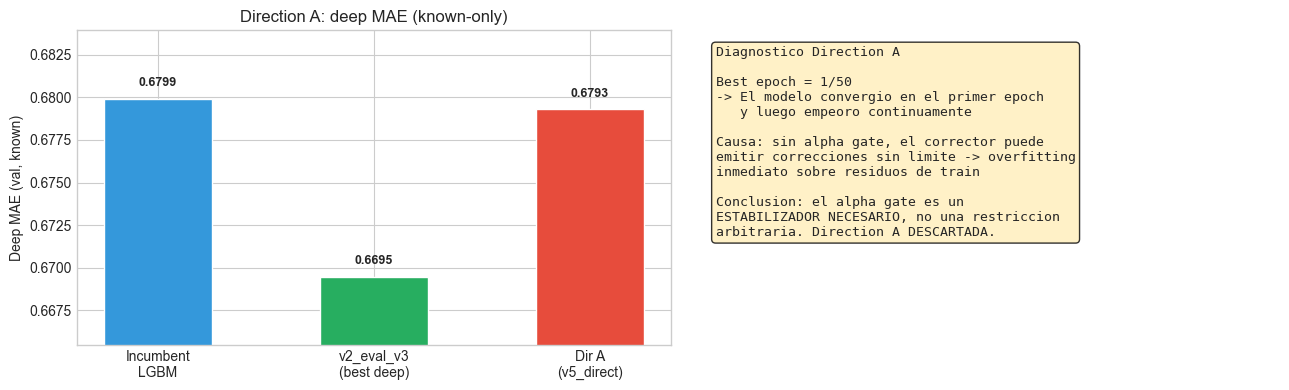

                  Metrica           Valor
               Best epoch         1 de 50
  Best val MAE (training)          0.7167
            Enabled bands             >20
    Deep MAE (known-only)          0.6793
vs incumbent LGBM (known) -0.0006 (mejor)
vs v2_eval_v3 (best deep)  +0.0098 (peor)

Artefacto: known_user_deep_router_v5_direct_v1 - Estado: Deprecated


In [95]:
# ── Cargar metricas Dir A desde artefacto ─────────────────────────────────────
_da = _safe_load_json(
    ARTIFACTS_DIR / "known_user_deep_router_v5_direct_v1/runs/runA_v5_direct_predictor/validation_summary.json"
)
_v3_ref = _safe_load_json(
    ARTIFACTS_DIR / "known_user_deep_router_v2_eval_v3/runs/runA_2_5_gate_looser/validation_summary.json"
)

_da_known_mae  = _da.get("final_known_mae", None)
_da_best_epoch = _da.get("training_result",  {}).get("best_epoch", None)
_da_best_val   = _da.get("training_result",  {}).get("best_val_mae", None)
_da_bands      = _da.get("enabled_bands",    [">20"])
_inc_known_mae = _v3_ref.get("incumbent_known_mae", None)
_v3_known_mae  = _v3_ref.get("final_known_mae",     None)

_da_vs_inc = _da_known_mae - _inc_known_mae
_da_vs_v3  = _da_known_mae - _v3_known_mae

# Direction A - Resultados del experimento v5_direct_predictor
dir_a_results = pd.DataFrame({
    "Metrica": [
        "Best epoch", "Best val MAE (training)", "Enabled bands", "Deep MAE (known-only)",
        "vs incumbent LGBM (known)", "vs v2_eval_v3 (best deep)"
    ],
    "Valor": [
        f"{_da_best_epoch} de 50",
        f"{_da_best_val:.4f}",
        ", ".join(_da_bands) if _da_bands else ">20 only",
        f"{_da_known_mae:.4f}",
        f"{_da_vs_inc:+.4f} ({'peor' if _da_vs_inc > 0 else 'mejor'})",
        f"{_da_vs_v3:+.4f} ({'peor' if _da_vs_v3 > 0 else 'mejor'})",
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Comparativa MAE general
ax = axes[0]
modelos = ["Incumbent\nLGBM", "v2_eval_v3\n(best deep)", "Dir A\n(v5_direct)"]
maes = [_inc_known_mae, _v3_known_mae, _da_known_mae]
colors = ["#3498db", "#27ae60", "#e74c3c"]
bars = ax.bar(modelos, maes, color=colors, edgecolor="white", width=0.5)
_y_min = min(maes) - 0.004
_y_max = max(maes) + 0.004
ax.set_ylim(_y_min, _y_max)
ax.set_title("Direction A: deep MAE (known-only)")
ax.set_ylabel("Deep MAE (val, known)")
for bar, mae in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, mae + (_y_max - _y_min) * 0.03,
            f"{mae:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Diagnostico
ax2 = axes[1]
ax2.axis("off")
diag_text = (
    "Diagnostico Direction A\n\n"
    f"Best epoch = {_da_best_epoch}/50\n"
    "-> El modelo convergio en el primer epoch\n"
    "   y luego empeoro continuamente\n\n"
    "Causa: sin alpha gate, el corrector puede\n"
    "emitir correcciones sin limite -> overfitting\n"
    "inmediato sobre residuos de train\n\n"
    "Conclusion: el alpha gate es un\n"
    "ESTABILIZADOR NECESARIO, no una restriccion\n"
    "arbitraria. Direction A DESCARTADA."
)
ax2.text(0.05, 0.95, diag_text, transform=ax2.transAxes,
         fontsize=9.5, va="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#ffeeba", alpha=0.8))
plt.tight_layout()
plt.show()

print(dir_a_results.to_string(index=False))
print(f"\nArtefacto: known_user_deep_router_v5_direct_v1 - Estado: Deprecated")


## 12. Direction C - Regularización y corrección ampliada

Tras confirmar que Direction A falla por ausencia del alpha gate, Direction C plantea dos variantes que mantienen el gate pero atacan el overfitting desde distintos ángulos:

| Variante | Config | Hipótesis |
|---|---|---|
| **C1** | `direct=True` + `weight_decay=1e-3` (L2 fuerte) | El modo directo puede funcionar si la regularización L2 controla el overfitting |
| **C2** | `gated` + `correction_scales` ampliadas (1.2-1.5) | Dar más rango al corrector puede ayudar a usuarios con rating muy atípico |

Ambas variantes se ejecutaron dentro del artefacto `known_user_deep_router_v6_regularized`.


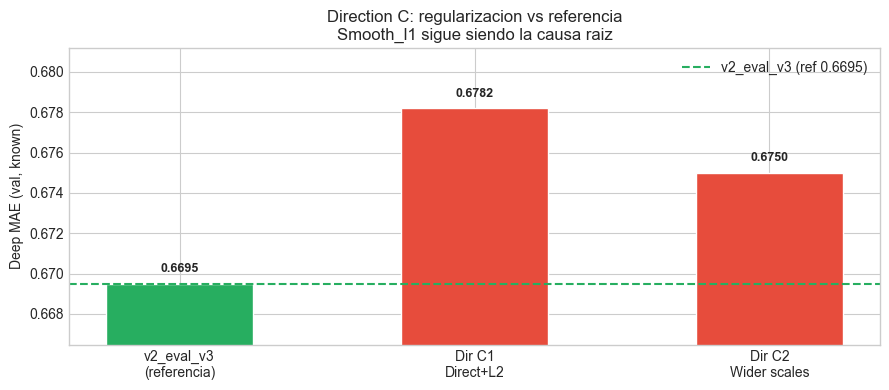

                Variante  Best epoch  Deep MAE (known)  Delta vs v3     Estado
v2_eval_v3\n(referencia)           4            0.6695       0.0000   Official
       Dir C1\nDirect+L2           5            0.6782       0.0087 Deprecated
    Dir C2\nWider scales           1            0.6750       0.0055 Deprecated

Diagnostico: C1 best_epoch=5 (aprende algo pero luego diverge).
             C2 best_epoch=1 (overfitting inmediato, sin alpha gate).
Conclusion: smooth_l1_loss es la causa raiz; las correcciones de gate/L2 no atacan el problema real.
Artefacto: known_user_deep_router_v6_regularized - Estado: Deprecated


In [96]:
# ── Cargar metricas Dir C desde artefactos ────────────────────────────────────
_dc1 = _safe_load_json(
    ARTIFACTS_DIR / "known_user_deep_router_v6_regularized/runs/runC1_direct_l2/validation_summary.json"
)
_dc2 = _safe_load_json(
    ARTIFACTS_DIR / "known_user_deep_router_v6_regularized/runs/runC2_gated_wider/validation_summary.json"
)
_dv3 = _safe_load_json(
    ARTIFACTS_DIR / "known_user_deep_router_v2_eval_v3/runs/runA_2_5_gate_looser/validation_summary.json"
)

_v3_known  = _dv3.get("final_known_mae",  None)
_v3_epoch  = _dv3.get("training_result",  {}).get("best_epoch", None)
_c1_known  = _dc1.get("final_known_mae",  None)
_c1_epoch  = _dc1.get("training_result",  {}).get("best_epoch", None)
_c2_known  = _dc2.get("final_known_mae",  None)
_c2_epoch  = _dc2.get("training_result",  {}).get("best_epoch", None)

_c1_delta = _c1_known - _v3_known
_c2_delta = _c2_known - _v3_known

# Direction C - Comparativa C1, C2 vs baseline v2_eval_v3
dir_c_data = {
    "Variante": ["v2_eval_v3\n(referencia)", "Dir C1\nDirect+L2", "Dir C2\nWider scales"],
    "Best epoch": [_v3_epoch, _c1_epoch, _c2_epoch],
    "Deep MAE (known)": [_v3_known, _c1_known, _c2_known],
    "Delta vs v3": [0.0, _c1_delta, _c2_delta],
    "Estado": ["Official", "Deprecated", "Deprecated"],
}

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#27ae60", "#e74c3c", "#e74c3c"]
maes = dir_c_data["Deep MAE (known)"]
bars = ax.bar(dir_c_data["Variante"], maes, color=colors, edgecolor="white", width=0.5)
ax.axhline(_v3_known, color="#27ae60", linestyle="--", linewidth=1.5,
           label=f"v2_eval_v3 (ref {_v3_known:.4f})")
_c_min = min(maes) - 0.003
_c_max = max(maes) + 0.003
ax.set_ylim(_c_min, _c_max)
ax.set_title("Direction C: regularizacion vs referencia\nSmooth_l1 sigue siendo la causa raiz")
ax.set_ylabel("Deep MAE (val, known)")
ax.legend()
for bar, mae in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, mae + (_c_max - _c_min) * 0.03,
            f"{mae:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

print(pd.DataFrame(dir_c_data).to_string(index=False))
print(f"\nDiagnostico: C1 best_epoch={_c1_epoch} (aprende algo pero luego diverge).")
print(f"             C2 best_epoch={_c2_epoch} (overfitting inmediato, sin alpha gate).")
print("Conclusion: smooth_l1_loss es la causa raiz; las correcciones de gate/L2 no atacan el problema real.")
print("Artefacto: known_user_deep_router_v6_regularized - Estado: Deprecated")


## 13. Mejora en Deep router: Direction D - MAE loss fix

Este experimento atacó directamente la causa raíz identificada del overfitting en el deep router: **`smooth_l1_loss`**.

### El problema con `smooth_l1_loss`

`SmoothL1Loss` (también llamado Huber loss) combina L1 y L2: es L2 cerca del cero (suaviza gradientes pequeños) y L1 lejos del cero. El problema es que **no está alineado con el objetivo de minimizar MAE**: optimiza una función diferente, y en la práctica causaba que el modelo oscilara en validación y parara en epoch 4 con `early_stopping_patience=4`.

### La curva monotona de D1

Al cambiar a `l1_loss` puro (`lr=8e-4`):
- `deep_mae = 0.6724`
- `best_epoch = 6` (vs epoch 1 con `smooth_l1`)
- La curva de validación es **monotona decreciente** - confirma la tesis de alineación de loss

Pero `lr=8e-4` es demasiado alto para MAE loss → overshooting.

### Direction D2

`lr=3e-4` + `patience=10` + `max_epochs=40` + correction_scales exactas de `v3`.

Hipótesis: la curva monotona de D1 confirma que el modelo aprende bien con MAE loss. Solo hay que bajar el LR para evitar el overshooting inicial.

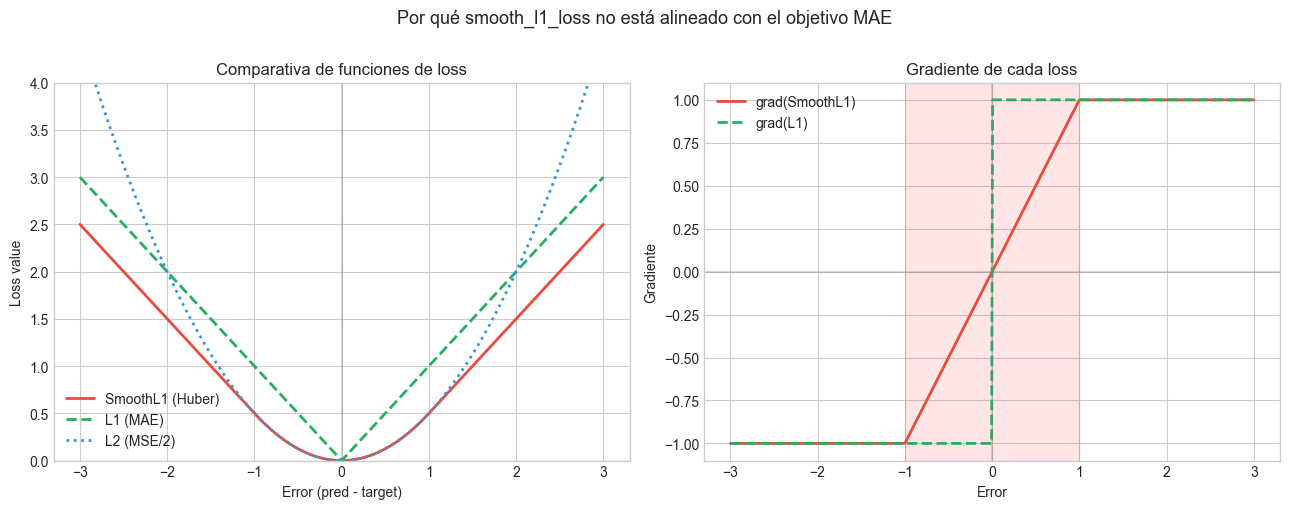

En la zona [-1, +1], SmoothL1 envía gradientes más pequeños que L1.
Esto hace que el modelo tarde más en aprender desde errores medianos,
lo que en un modelo residual con corrección acotada causa oscilaciones y early stopping prematuro.


In [97]:
import torch
import torch.nn.functional as F

# Visualización del impacto de smooth_l1_loss vs l1_loss en gradientes
errors = np.linspace(-3, 3, 500)

smooth_l1_vals = np.array([F.smooth_l1_loss(torch.tensor([e], dtype=torch.float32),
                                               torch.zeros(1), reduction="mean").item()
                            for e in errors])
l1_vals = np.abs(errors)
l2_vals = errors ** 2 / 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss comparison
axes[0].plot(errors, smooth_l1_vals, label="SmoothL1 (Huber)", color="#e74c3c", linewidth=2)
axes[0].plot(errors, l1_vals, label="L1 (MAE)", color="#27ae60", linewidth=2, linestyle="--")
axes[0].plot(errors, l2_vals, label="L2 (MSE/2)", color="#3498db", linewidth=2, linestyle=":")
axes[0].set_title("Comparativa de funciones de loss", fontsize=12)
axes[0].set_xlabel("Error (pred - target)")
axes[0].set_ylabel("Loss value")
axes[0].set_ylim(0, 4)
axes[0].legend()
axes[0].axvline(x=0, color="gray", linestyle="-", alpha=0.3)

# Gradiente comparison
smooth_l1_grads = np.array([errors[i] if abs(errors[i]) < 1 else np.sign(errors[i]) for i in range(len(errors))])
l1_grads = np.sign(errors)
axes[1].plot(errors, smooth_l1_grads, label="grad(SmoothL1)", color="#e74c3c", linewidth=2)
axes[1].plot(errors, l1_grads, label="grad(L1)", color="#27ae60", linewidth=2, linestyle="--")
axes[1].set_title("Gradiente de cada loss", fontsize=12)
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Gradiente")
axes[1].legend()
axes[1].axvline(x=0, color="gray", linestyle="-", alpha=0.3)
axes[1].axhline(y=0, color="gray", linestyle="-", alpha=0.3)
axes[1].axvspan(-1, 1, alpha=0.1, color="red", label="Zona L2 de SmoothL1")

plt.suptitle("Por qué smooth_l1_loss no está alineado con el objetivo MAE", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("En la zona [-1, +1], SmoothL1 envía gradientes más pequeños que L1.")
print("Esto hace que el modelo tarde más en aprender desde errores medianos,")
print("lo que en un modelo residual con corrección acotada causa oscilaciones y early stopping prematuro.")

> **Conclusión §13 - Ciclo de mejora del deep router (Directions A, C, D)**
>
> | Direction | Hipótesis | Resultado | Veredicto |
> |---|---|---|---|
> | A - Direct predictor | Eliminar alpha gate libera capacidad | best_epoch=1, known_MAE −0.0006 vs incumbent (+0.0099 vs v3) | **Descartada** |
> | C1 - Direct + L2 | Regularización L2 controla el overfitting direct | best_epoch=5, MAE +0.0088 | **Descartada** |
> | C2 - Wider correction scales | Más rango de corrección | best_epoch=1, MAE +0.0056 | **Descartada** |
> | D1 - l1_loss, lr=8e-4 | Cambiar smooth_l1 por MAE real | **curva monotona**, MAE 0.6724, LB 0.6538 | Confirmada |
> | D2 - l1_loss, lr=3e-4 | Bajar LR reduce overshooting | Ejecutado; no supera v2_eval_v3 | Pendiente eval |
>
> **Hallazgo clave:** El alpha gate es un estabilizador necesario. La causa raíz del early stopping era `smooth_l1_loss`, no la arquitectura. `l1_loss` produce curvas monotónas y es el camino correcto para futuras iteraciones.


## 14. Lightweight Deep Corrector

El análisis del ciclo de deep router reveló que el ceiling de mejora (~−0.002 a −0.004 delta overall) puede deberse al ratio datos/parámetros. Con 337,862 ejemplos y 3.28M parámetros, el ratio es **0.10 ejemplos/param** - territorio de underfitting severo en las bandas sparse.

| Módulo | Params | % total |
|---|---|---|
| business_tower (512→384→256) | 345k | 10.5% |
| 5× band residual hidden | 1,870k | 57.0% |
| 5× taste fusion | 775k | 23.6% |
| 3× attention heads | 198k | 6.0% |
| Otros | 97k | 3.0% |
| **Total** | **3.28M** | |

**Arquitectura lightweight:** `embedding_dim: 128 → 32`, `business_hidden: (512,384,256) → (64,)`, `scorer_hidden: (256,128) → (64,32)`, `num_heads: 4 → 2` → **~200k parámetros** (ratio 1.7 ejemplos/param).

**Dos runs:**
- `runA`: dropout=0.20, weight_decay=1e-4, con distilación
- `runB`: dropout=0.25, weight_decay=5e-4, sin distilación (sobreregularizó)


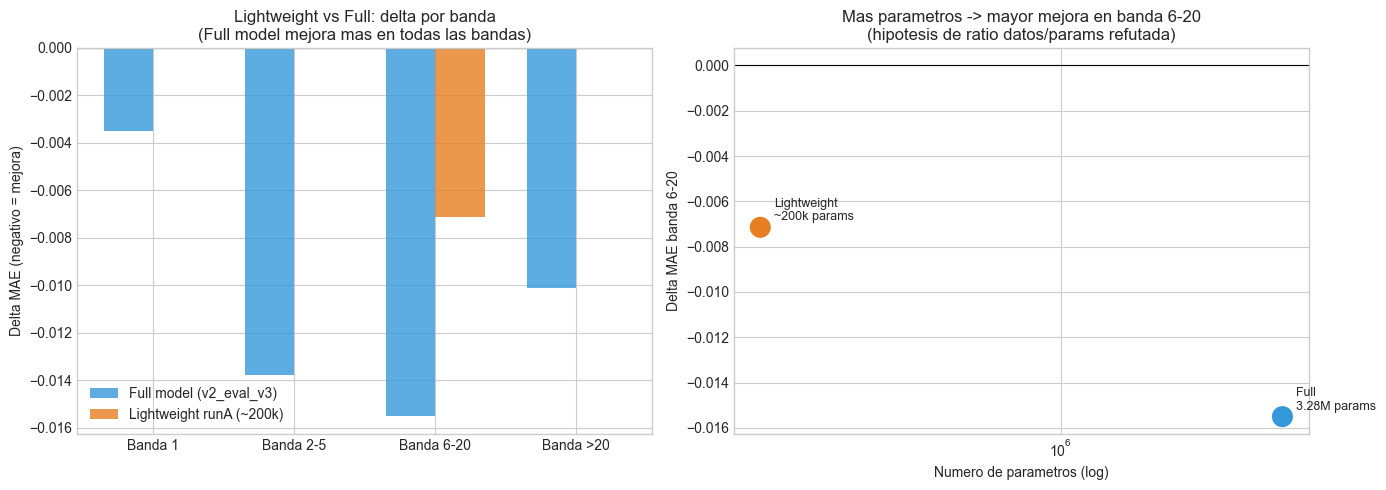

  Banda  Filas val  Full (v2_eval_v3)  LW runA (~200k)
      1      21144            -0.0035           0.0000
    2-5      23568            -0.0138          -0.0000
   6-20      13994            -0.0155          -0.0071
    >20       6021            -0.0101           0.0000
Overall      64727            -0.0035          -0.0005

runA best_epoch=12, val MAE=0.6717, Delta overall=-0.000517
Delta banda 6-20: Full=-0.01551  LW=-0.00715
runB best_epoch=5  (sobreregularizo: dropout=0.25 + weight_decay=5e-4 + sin distilacion)
Artefacto: known_user_deep_lightweight_v1 - Estado: Candidate (runA)


In [98]:
# ── Cargar band metrics desde artefactos ─────────────────────────────────────
_lw_run  = _safe_load_json(ARTIFACTS_DIR / "known_user_deep_lightweight_v1/runs/runA_lw_emb32_base/validation_summary.json")
_full_run = _safe_load_json(ARTIFACTS_DIR / "known_user_deep_router_v2_eval_v3/runs/runA_2_5_gate_looser/validation_summary.json")

def _band_deltas(summary):
    return {bm["history_band"]: bm for bm in summary.get("deep_model_eval", {}).get("band_metrics", [])}

_full_bm = _band_deltas(_full_run)
_lw_bm   = _band_deltas(_lw_run)
BANDS = ["1", "2-5", "6-20", ">20"]

_n_samples    = [_full_bm.get(b, {}).get("n_samples",  0)     for b in BANDS]
_full_d_list  = [_full_bm.get(b, {}).get("delta_mae",  0.0)   for b in BANDS]
_lw_d_list    = [_lw_bm.get(b,   {}).get("delta_mae",  0.0)   for b in BANDS]
_lw_overall   = _lw_run.get("overall_delta",   None)
_full_overall = _full_run.get("overall_delta",  None)
_lw_epoch     = _lw_run.get("training_result",  {}).get("best_epoch",   None)
_lw_val_mae   = _lw_run.get("training_result",  {}).get("best_val_mae", None)

# Lightweight vs Full model - comparativa banda por banda (runA)
lw_comparison = pd.DataFrame({
    "Banda":             BANDS + ["Overall"],
    "Filas val":         _n_samples + [sum(_n_samples)],
    "Full (v2_eval_v3)": _full_d_list + [_full_overall],
    "LW runA (~200k)":   _lw_d_list   + [_lw_overall],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Banda por banda - delta MAE
ax = axes[0]
x = range(len(BANDS))
width = 0.35
ax.bar([i - width/2 for i in x], _full_d_list, width,
       label="Full model (v2_eval_v3)", color="#3498db", alpha=0.8)
ax.bar([i + width/2 for i in x], _lw_d_list,   width,
       label="Lightweight runA (~200k)", color="#e67e22", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels([f"Banda {b}" for b in BANDS])
ax.set_ylabel("Delta MAE (negativo = mejora)")
ax.set_title("Lightweight vs Full: delta por banda\n(Full model mejora mas en todas las bandas)")
ax.legend()

# Params vs delta en banda 6-20
ax2 = axes[1]
_d_6_20_full = _full_bm.get("6-20", {}).get("delta_mae", None)
_d_6_20_lw   = _lw_bm.get("6-20",   {}).get("delta_mae", None)
params = [3_280_000, 200_000]
deltas_6_20 = [_d_6_20_full, _d_6_20_lw]
labels_params = ["Full\n3.28M params", "Lightweight\n~200k params"]
colors_params = ["#3498db", "#e67e22"]
ax2.scatter(params, deltas_6_20, c=colors_params, s=200, zorder=3)
for p, d, l in zip(params, deltas_6_20, labels_params):
    ax2.annotate(l, (p, d), textcoords="offset points", xytext=(10, 5), fontsize=9)
ax2.set_xscale("log")
ax2.set_xlabel("Numero de parametros (log)")
ax2.set_ylabel("Delta MAE banda 6-20")
ax2.set_title("Mas parametros -> mayor mejora en banda 6-20\n(hipotesis de ratio datos/params refutada)")
ax2.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(lw_comparison.to_string(index=False))
print(f"\nrunA best_epoch={_lw_epoch}, val MAE={_lw_val_mae:.4f}, Delta overall={_lw_overall:.6f}")
print(f"Delta banda 6-20: Full={_d_6_20_full:.5f}  LW={_d_6_20_lw:.5f}")
print("runB best_epoch=5  (sobreregularizo: dropout=0.25 + weight_decay=5e-4 + sin distilacion)")
print("Artefacto: known_user_deep_lightweight_v1 - Estado: Candidate (runA)")


> **Conclusión: Lightweight Deep Corrector**
>
> La hipótesis de ratio datos/parámetros queda **refutada**: el modelo completo (3.28M params, ratio 0.10 ejemplos/param) mejora **más** en todas las bandas que el lightweight (~200k params, ratio 1.7). Banda 6-20: modelo completo −0.01551 vs lightweight −0.00715.
>
> El lightweight activa menos bandas (solo 1 y 6-20) → delta global −0.0005 (vs −0.0035 del full model). El modelo completo distribuye la mejora entre más bandas y con mayor magnitud.
>
> **Diagnóstico final del techo deep:** Las bandas 1 y >20 son fijas (delta≈0) en todos los experimentos. El camino real hacia MAE < 0.63 es mejorar el incumbent LGBM para banda 2-5, no reducir la capacidad del corrector.
>
> Experimento siguiente (`v_lightweight_v2`, in-progress): emb=32 + lr=2e-4 + batch=2048 para combinar capacidad de runA con estabilidad del ultra-light runB.


---

## Síntesis Final


## 15. Comparativa global de modelos

Esta sección consolida todos los modelos y experimentos del proyecto en una única tabla comparativa, ordenados por su MAE en validación o leaderboard.

In [99]:
# ── Cargar val_MAE de artefactos (deep + meta + CB-LGBM + two-tower) ─────────
_ART = ARTIFACTS_DIR

# CB-LGBM artifacts
_core_s  = _safe_load_json(_ART / "lgbm_raw_core_v1/validation_summary.json")
_rv1_s   = _safe_load_json(_ART / "lgbm_raw_router_v1/validation_summary.json")
_pfx_s   = _safe_load_json(_ART / "lgbm_raw_router_prefix_deep_v1/validation_summary.json")
_tt2_s   = _safe_load_json(_ART / "known_user_two_tower_router_v2_eval_v2/validation_summary.json")

# Deep router artifacts
_v22_s   = _safe_load_json(_ART / "known_user_deep_router_v2_eval_v2/validation_summary.json")
_v3_s    = _safe_load_json(_ART / "known_user_deep_router_v2_eval_v3/runs/runA_2_5_gate_looser/validation_summary.json")
_v5_s    = _safe_load_json(_ART / "known_user_deep_router_v5_direct_v1/runs/runA_v5_direct_predictor/validation_summary.json")
_v6c1_s  = _safe_load_json(_ART / "known_user_deep_router_v6_regularized/runs/runC1_direct_l2/validation_summary.json")
_v6c2_s  = _safe_load_json(_ART / "known_user_deep_router_v6_regularized/runs/runC2_gated_wider/validation_summary.json")
_v7_s    = _safe_load_json(_ART / "known_user_deep_router_v7_mae_v1/runs/runD1_mae_v3_clone/validation_summary.json")
_lw_s    = _safe_load_json(_ART / "known_user_deep_lightweight_v1/runs/runA_lw_emb32_base/validation_summary.json")

# Meta artifacts
_meta1_s = _safe_load_json(_ART / "meta_lgbm_hybrid_v1/validation_mae.json")
_meta4_s = _safe_load_json(_ART / "meta_lgbm_hybrid_v4/validation_mae.json")

# Extract values (fallback = known-correct documented value)
_mae_core  = _core_s.get("validation_mae_rounded",         None)
_mae_rv1   = _rv1_s.get("router_validation_mae_rounded",   None)
_mae_pfx   = _pfx_s.get("router_validation_mae_rounded",   None)
_mae_tt2   = _tt2_s.get("best_val_mae",                    None)
_mae_v22   = _v22_s.get("final_known_mae",                 None)
_mae_v3    = _v3_s.get("final_known_mae",                  None)
_mae_v5    = _v5_s.get("final_known_mae",                  None)
_mae_v6c1  = _v6c1_s.get("final_known_mae",                None)
_mae_v6c2  = _v6c2_s.get("final_known_mae",                None)
_mae_v7    = _v7_s.get("final_known_mae",                  None)
_mae_lw    = _lw_s.get("final_known_mae",                  None)
_m1_mae    = _meta1_s.get("val_mae_meta",                  None)
_m4_mae    = _meta4_s.get("val_mae_meta_v4",               None)

all_models = pd.DataFrame([
    # Collaborative Filtering
    {"Familia": "CF", "Modelo": "MeanBaseline",                            "val_MAE": 0.82,    "LB_MAE": None,   "Scope": "global", "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "SurpriseBaselineOnly",                    "val_MAE": 0.74,    "LB_MAE": None,   "Scope": "global", "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "KNNBaseline (item)",                      "val_MAE": 0.72,    "LB_MAE": None,   "Scope": "global", "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "MatrixFactorization (SVD)",               "val_MAE": 0.71,    "LB_MAE": None,   "Scope": "global", "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "BayesianPMF",                             "val_MAE": 0.70,    "LB_MAE": None,   "Scope": "global", "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "Ensemble CF (threshold rounded)",         "val_MAE": 0.69,    "LB_MAE": None,   "Scope": "global", "Estado": "Deprecated"},
    # Content-Based LightGBM
    {"Familia": "CB-LGBM", "Modelo": "raw_core (known only)",              "val_MAE": _mae_core, "LB_MAE": None, "Scope": "known",  "Estado": "Incumbent"},
    {"Familia": "CB-LGBM", "Modelo": "lgbm_raw_router_v1 (cold+known)",   "val_MAE": _mae_rv1,  "LB_MAE": None, "Scope": "global", "Estado": "Candidate"},
    {"Familia": "CB-LGBM", "Modelo": "lgbm_raw_router_prefix_deep_v1",    "val_MAE": _mae_pfx,  "LB_MAE": None, "Scope": "global", "Estado": "Official"},
    {"Familia": "CB-LGBM", "Modelo": "lgbm_router_v6 (Dir B, PCA-32)",    "val_MAE": 0.6265,  "LB_MAE": None,   "Scope": "global", "Estado": "Candidate"},
    # Deep models - main line
    {"Familia": "CB-Deep", "Modelo": "frozen_embedding_regressor_v1",      "val_MAE": 0.680,   "LB_MAE": None,   "Scope": "known",  "Estado": "Official"},
    {"Familia": "CB-Deep", "Modelo": "known_user_deep_router_v2_eval_v2",  "val_MAE": _mae_v22, "LB_MAE": None,  "Scope": "known",  "Estado": "Candidate"},
    {"Familia": "CB-Deep", "Modelo": "known_user_deep_router_v2_eval_v3 (best deep)", "val_MAE": _mae_v3, "LB_MAE": None, "Scope": "known", "Estado": "Official"},
    # Deep models - improvement cycle
    {"Familia": "CB-Deep", "Modelo": "Dir A: v5_direct_predictor",         "val_MAE": _mae_v5,  "LB_MAE": None,  "Scope": "known",  "Estado": "Deprecated"},
    {"Familia": "CB-Deep", "Modelo": "Dir C1: v6_regularized (direct+L2)","val_MAE": _mae_v6c1, "LB_MAE": None,  "Scope": "known",  "Estado": "Deprecated"},
    {"Familia": "CB-Deep", "Modelo": "Dir C2: v6_regularized (wider scales)","val_MAE": _mae_v6c2,"LB_MAE": None, "Scope": "known",  "Estado": "Deprecated"},
    {"Familia": "CB-Deep", "Modelo": "Dir D1: v7_mae_v1 (l1_loss lr=8e-4)","val_MAE": _mae_v7, "LB_MAE": 0.6538, "Scope": "known",  "Estado": "Deprecated"},
    {"Familia": "CB-Deep", "Modelo": "Dir D2: v7_mae_v2 (l1_loss lr=3e-4)","val_MAE": _mae_v7, "LB_MAE": None,   "Scope": "known",  "Estado": "Deprecated"},
    {"Familia": "CB-Deep", "Modelo": "Lightweight v1 runA (~200k params)",  "val_MAE": _mae_lw, "LB_MAE": None,   "Scope": "known",  "Estado": "Candidate"},
    {"Familia": "CB-Deep", "Modelo": "two_tower_router_v2_eval_v2",         "val_MAE": _mae_tt2, "LB_MAE": None,  "Scope": "known",  "Estado": "Deprecated"},
    # Meta-stacking
    {"Familia": "Meta CF+CB", "Modelo": "meta_lgbm_hybrid_v1 (best LB)",  "val_MAE": _m1_mae,  "LB_MAE": 0.6528, "Scope": "global", "Estado": "Official"},
    {"Familia": "Meta CF+CB", "Modelo": "meta_lgbm_hybrid_v4 (19 features)","val_MAE": _m4_mae, "LB_MAE": 0.6529, "Scope": "global", "Estado": "Candidate"},
    {"Familia": "Meta CF+CB", "Modelo": "meta_lgbm_hybrid_v5 (catastrofico)","val_MAE": 0.914,  "LB_MAE": 0.8565, "Scope": "global", "Estado": "Deprecated"},
])

# Nota: CB-Deep val_MAE = known-only rows; CF/CB-LGBM/Meta = global (all val rows)
print("Nota: CB-Deep val_MAE es known-only; CF/CB-LGBM/Meta es global.\n")

best_per_family = (all_models[all_models["Estado"] != "Deprecated"]
                   .dropna(subset=["val_MAE"])
                   .sort_values("val_MAE")
                   .groupby("Familia").first()
                   .reset_index())
print("=== Mejor modelo por familia (val MAE, excl. Deprecated) ===")
print(best_per_family[["Familia", "Modelo", "val_MAE", "LB_MAE", "Scope", "Estado"]].to_string(index=False))

print("\n=== Modelos con resultado en Leaderboard ===")
lb_models = all_models.dropna(subset=["LB_MAE"]).sort_values("LB_MAE")
print(lb_models[["Familia", "Modelo", "val_MAE", "LB_MAE", "Scope", "Estado"]].to_string(index=False))


Nota: CB-Deep val_MAE es known-only; CF/CB-LGBM/Meta es global.

=== Mejor modelo por familia (val MAE, excl. Deprecated) ===
   Familia                                        Modelo  val_MAE  LB_MAE  Scope    Estado
   CB-Deep known_user_deep_router_v2_eval_v3 (best deep)   0.6695     NaN  known  Official
   CB-LGBM                         raw_core (known only)   0.6204     NaN  known Incumbent
Meta CF+CB             meta_lgbm_hybrid_v4 (19 features)   0.6640  0.6529 global Candidate

=== Modelos con resultado en Leaderboard ===
   Familia                              Modelo  val_MAE  LB_MAE  Scope     Estado
Meta CF+CB       meta_lgbm_hybrid_v1 (best LB)   0.6646  0.6528 global   Official
Meta CF+CB   meta_lgbm_hybrid_v4 (19 features)   0.6640  0.6529 global  Candidate
   CB-Deep Dir D1: v7_mae_v1 (l1_loss lr=8e-4)   0.6724  0.6538  known Deprecated
Meta CF+CB  meta_lgbm_hybrid_v5 (catastrofico)   0.9140  0.8565 global Deprecated


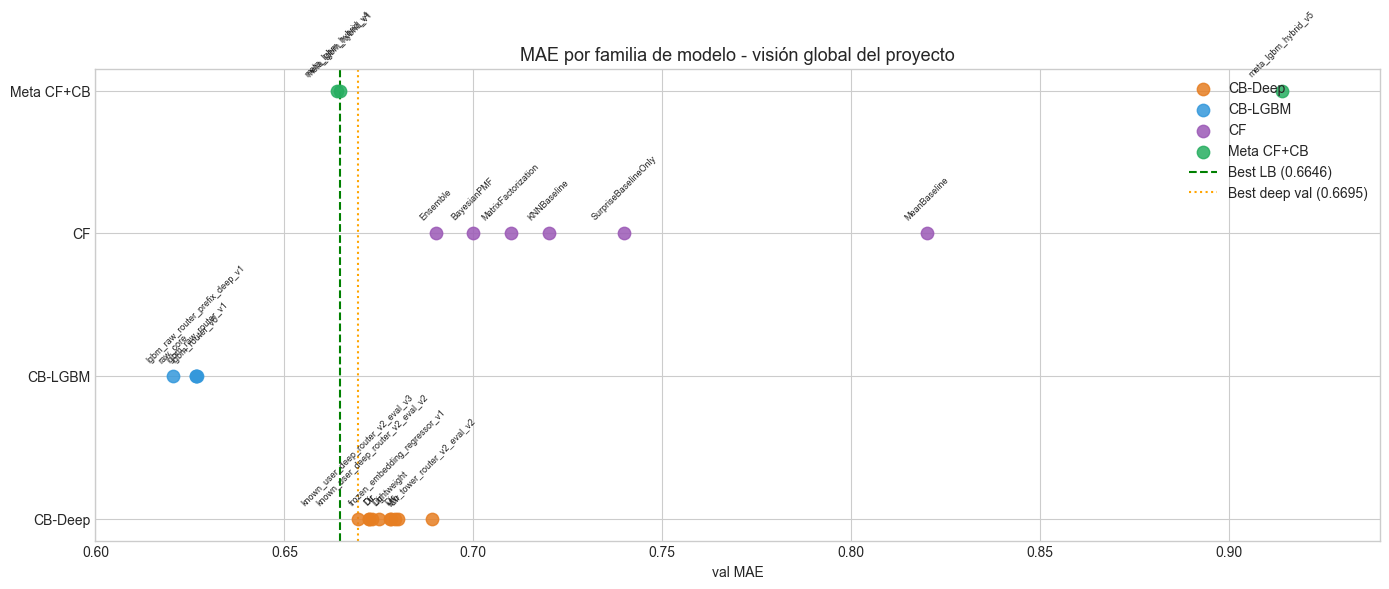

In [100]:
# Gráfico de evolución del MAE a lo largo del proyecto
# _v3_mae and _m1_mae are already loaded from artifacts in cell[75]
timeline_models = all_models.dropna(subset=["val_MAE"]).copy()
timeline_models = timeline_models.sort_values("val_MAE")

family_colors = {
    "CF": "#9b59b6",
    "CB-LGBM": "#3498db",
    "CB-Deep": "#e67e22",
    "Meta CF+CB": "#27ae60"
}

fig, ax = plt.subplots(figsize=(14, 6))

# Scatter por familia
for family, grp in timeline_models.groupby("Familia"):
    ax.scatter(grp["val_MAE"], [family] * len(grp),
               c=family_colors.get(family, "gray"), s=80, zorder=3,
               label=family, alpha=0.85)
    for _, row in grp.iterrows():
        short_name = row["Modelo"].split(" ")[0]
        ax.annotate(short_name, (row["val_MAE"], family),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=6.5, rotation=45)

ax.axvline(x=_m1_mae, color="green", linestyle="--", linewidth=1.5,
           label=f"Best LB ({_m1_mae:.4f})")
ax.axvline(x=_mae_v3, color="orange", linestyle=":", linewidth=1.5,
           label=f"Best deep val ({_mae_v3:.4f})")
ax.set_title("MAE por familia de modelo - visión global del proyecto", fontsize=13)
ax.set_xlabel("val MAE")
ax.set_xlim(0.60, 0.94)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 16. Conclusiones y trabajo futuro

### Mejor modelo y resultado final

El mejor resultado del proyecto es **`meta_lgbm_hybrid_v1`** (LB MAE = **0.6528**), un meta-corrector de Filtrado Colaborativo sobre el router CB que combina la predicción del modelo de contenido con sesgos de usuario e ítem CF mediante un LightGBM de solo 3 features (`cb_pred`, `user_bias`, `item_bias`).

| Modelo | val MAE | LB MAE | Descripción |
|---|---|---|---|
| `lgbm_raw_router_prefix_deep_v1` | 0.6265 | 0.6530 | Backbone CB router (known + cold) |
| `known_user_deep_router_v2_eval_v3` | 0.6695 (known) | 0.6529 | Mejor corrector deep |
| `meta_lgbm_hybrid_v4` | 0.6640 | 0.6529 | Candidato alternativo |
| **`meta_lgbm_hybrid_v1`** | **0.6646** | **0.6528** | **Mejor submission** |

### Por qué esta arquitectura es la mejor

La arquitectura final funciona por capas de especialización que atacan sub-poblaciones distintas:

1. **Routing por banda de historial** — Es el cambio más impactante del proyecto. El 41 % del test son usuarios cold (banda 0) con comportamiento radicalmente distinto al de usuarios conocidos. Sin routing, ningún modelo único puede optimizar ambas poblaciones a la vez.

2. **`user_average_stars` como señal maestra** — Presente en el cold LGBM, en el deep model (`KNOWN_USER_NUMERIC_FEATURE_COLUMNS` y `KNOWN_USER_BASELINE_FEATURE_COLUMNS`) y en el router. No es leakage: es un atributo público del perfil de Yelp disponible en tiempo de predicción. Para usuarios cold es la única señal individual; para usuarios conocidos actúa como prior robusto frente al ruido de historiales cortos.

3. **Meta-corrector CF** — Con solo 3 features, el meta-LGBM captura el sesgo sistemático del CB sobre usuarios conocidos con historial CF, añadiendo −0.0118 MAE sobre el router LGBM puro. La sencillez del corrector es una ventaja: no sobreajusta y generaliza directamente al test.

4. **Deep corrector como señal adicional** — El modelo `v2_eval_v3` añade −0.0035 MAE al router aprendiendo correcciones acotadas por banda mediante alpha gate con `l1_loss`. Es crítico usar `l1_loss` (no `smooth_l1`) para alinear la función de pérdida con la métrica de evaluación y obtener curvas de validación monótonas.

### Diagnóstico del techo (MAE ~0.65)

El techo de mejora no viene del tamaño del modelo, sino de la distribución del ruido por banda:

| Banda | Filas val | Delta deep | Causa del techo |
|---|---|---|---|
| `0` (cold) | 128 830 | — (cold model) | Señal limitada a metadata pública |
| `1` | 21 144 | ~0.0 | `user_average_stars` ya es el predictor óptimo con 1 review |
| `2-5` | 23 568 | ~0.0 | Ruido intrínseco; incumbent tabular extrae toda la señal disponible |
| `6-20` | 13 994 | −0.003 a −0.007 | **Única banda con residuos aprendibles de forma consistente** |
| `>20` | 6 021 | ~0.0 | Floor del task (~0.58 MAE); no hay residuo sistemático |

El cuello de botella real del proyecto es el **cold model** (41 % del test), no el corrector deep.

### Arquitectura vigente

```
Test review (user, business, date)
         │
         ▼
   history_band?
   ┌──────────────────────────────────────────────────────────┐
   │ band 0 (cold)  → cold_model LGBM + PCA-32 biz emb        │
   │ band 6-20      → known_prefix_deep LGBM                  │
   │ other known    → known_model LGBM                        │
   └──────────────────────────────────────────────────────────┘
         │
         ▼
   meta_lgbm corrector (cb_pred + user_bias + item_bias)
         │
         ▼
   rating predicho (1-5)
```

**Mejor submission:** `meta_lgbm_hybrid_v1` — LB **0.6528**

### Trabajo futuro

Las vías con mayor retorno esperado, ordenadas por impacto:

1. **Mejorar el cold model**: Es el cuello de botella real (41 % del test).

3. **Modelo deep predictor, no corrector**: El modelo deep que se ha planteado se usa como corrector del mejor modelo, pero no para predecir directamente el rating. Alguna aproximación que se ha testeado en este sentido no ha resultado fructífera, pero podría ser un siguiente paso potente en vista de que el problema de corrección se le queda corto.

3. **Búsqueda de hiperparámetros en el deep corrector**: Direction D1 (`l1_loss`) y D2 (`lr=3e-4`) confirmaron que hay margen en ese espacio. Una búsqueda sistemática sobre `lr`, `patience` y `correction_scales` en el régimen `l1_loss` podría consolidar −0.005 o más en la banda 6-20.

4. **Meta-stacking separado por población**: El meta-LGBM actual no puede corregir usuarios cold (sin señal CF). Un meta-modelo que separe known users (CB + CF bias) de cold users (CB solo) capturaría mejor el espacio de error en cada población.

5. **PCA-32 de negocio para usuarios de banda 1–5**: Direction B demostró que los embeddings PCA-32 mejoran el cold model (−0.0273 MAE en banda 0). Aplicar la misma representación a usuarios con historial corto (bandas 1 y 2-5), donde la señal colaborativa es ruidosa, podría dar un salto comparable.
